## ALGORITMOS GENÉTICOS - RUIDO DE MIDDLETON CLASE A

### Librerías

In [1]:
import numpy as np
import math
from scipy.special import factorial
import numpy.random as random

## Parámetros globales
- Parámetros rango de valores de los parámetros a estimar
        --A: [0.001;1]
        --Sigma_G2: [0.001;0.1]
        --gamma: [0.001;0.1]

In [3]:
A_min=0.01
A_max=1
sigma_min=0.001
sigma_max=1
gamma_min=0.001
gamma_max=0.1

## Definición de funciones

### Función generadora de ruido de middleton
Esta función genera muestra de Ruido de Middleton Clase A, considerando M términos de la sumatoria.

In [4]:
def RFI_MakeEnvelopeDataClassA(A,r,M,N,Sigmag2):
    """
    # Funcion generadora de muestras de envolvente de Ruido de Middleton de Clase A dados A,r,M,N,Sigmag2
    # INPUTS :
    #          A        : Parametro A del Ruido Clase A
    #          r        : Parametro gamma del Ruido de Clase A
    #          M        : Cantidad de terminos a ser considerados en la sumatoria de la pdf de Ruido de Clase A
    #          N        : Cantidad de muestras a ser generadas
    #          Sigmag2  : Potencia de Ruido Gaussiano o Background Noise
    # OUTPUTS:
    #          env_data : Vector de 1xN muestras de envolvente de Ruido Clase A generadas
    """
    # Generacion de los pesos de las distintas Gaussianas segun el valor de M
    # --------------------------------------------------
    m_vec = np.array(list(range(0,M)))
    pdf_weights = math.exp(-A)*A**m_vec/factorial(m_vec)

    # --------------------------------------------------
    # Normalizacion del vector de pesos/probabilidades para usar en la funcion random.choice
    # ----------------------------------------
    pdf_weights = pdf_weights/sum(pdf_weights)

    # ----------------------------------------
    # Generacion de vactor con los valores de M segun las probabilidades dadas por pdf_weights para cada valor de M
    # --------------------------------------------------------------
    selectionMat = random.choice(m_vec,N,replace=True,p=pdf_weights)
    #print(selectionMat)

    # --------------------------------------------------------------
    # Inicializacion de los vectores env_data y noise data
    # ----------------------
    env_data = np.zeros(N)
    noise_data = np.zeros(N)

    # ----------------------
    # Inicializacion del vector de desviaciones estandar
    # --------------------
    sigma_sq = np.zeros(M)
    # --------------------

    # Bucle for para la generacion de los valores de envolvente
    # Estos valores son generados de forma Normalizada, luego hay que desnormalizar con respecto al Ruido Gaussiano y r
    # -------------------------------------------------------------------
    for m in range(M):
        sigma_sq[m]        = (m/A + r) / (1 + r)
        #print(sigma_sq)
        inds               = np.where(selectionMat == m)
        inds               = inds[0]
        #print(inds)
        mean               = np.zeros(2)
        #print(mean)
        cov                = sigma_sq[m]*np.identity(2)
        #print(cov)
        dim                = len(inds)
        #print(dim)
        noise_data         = random.multivariate_normal(mean, cov, dim).T
        #print(noise_data)
        env_data[inds]     = (noise_data[0]**2 + noise_data[1]**2)**(1/2)
        #print(env_data)

    # -------------------------------------------------------------------
    # Datos env_data Normalizados
    env_data_Norm = env_data/np.sqrt(np.mean(env_data**2/2))

    # Calculo de constante de desnormalizacion
    # -------------------
    cte = Sigmag2*(1+1/r)
    # -------------------

    # Desnormalizacion
    # --------------------------------
    env_data_DesNorm = math.sqrt(cte)*env_data
    # --------------------------------

    return env_data_Norm,env_data_DesNorm

###  Función calculo de ECDf middleton de clase A (Función de Distribución Acumulada Excedida)

La ECDf (Exceedance Cumulative Distribution Function), también conocida como función de supervivencia o CCDF ($1 - \text{CDF}$) es fundamental para analizar ruido impulsivo, ya que representa la probabilidad de que la amplitud de una muestra supere un umbral determinado. Para el modelo de Middleton Clase A, la probabilidad de excedencia se define mediante la siguiente sumatoria ponderada:$$P(X > umbral) = e^{-A} \sum_{m=0}^{\infty} \frac{A^m}{m!} \exp\left( -\frac{I}{\sigma_m^2} \right)$$Donde:
- I: Potencia instántanéa desnormalizada, en escala lineal
- $A$ (Índice de impulsividad): Determina qué tan "puntiagudo" es el ruido. Valores bajos de $A$ indican una presencia fuerte de picos o eventos impulsivos.
- $m$: Representa el número de fuentes de interferencia activas simultáneamente.
- $\sigma_m^2$: Es la varianza de cada término, ajustada según la relación de potencias 
- ($r$) entre el componente gaussiano y el componente impulsivo.

Implementación Numérica y Escala Logarítmica: Debido al amplio rango dinámico de las señales acústicas capturadas por el receptor, el eje de amplitudes (abcisas) se procesa en escala logarítmica (dB). Esto permite una mejor visualización de las "colas" de la distribución, donde residen los eventos de mayor energía. En el código, la evaluación se realiza mediante la transformación:$$I_{lineal} = 10^{I_{dB}/10}$$ Esto se refleja en la función de Python como np.exp(-L_m * (10**x)), donde x representa los bins normalizados (X_CDF / 10). Esta técnica asegura que el ajuste del modelo sea sensible tanto a los niveles bajos de ruido de fondo como a los picos de interferencia detectados por el hardware del receptor. 
Es común que los receptores presenten

Nota sobre el modelo físico y el receptor: Muchos receptores reales integran detectores de envolvente y amplificadores logarítmicos que entregan la señal procesada en escala de dB. Esta escala mapea el amplio rango dinámico del ruido impulsivo a los bins del histograma de forma lineal. Por ello, la función realiza la transformación 10**(X_CDF/10) para reconvertir los bins a la escala de potencia necesaria para el ajuste con el modelo de Middleton Clase A.

In [5]:
def ECDF_middleton(X_CDF,V):
    # X_CDF son los bines o puntos a evaluar la función en dBw
    # V son los vectores de parámetros a evaluar, en el orden [A, 1/sigma_g2, r]
    #----------- Puntos iniciales ---------------
    A = V[0]
    r = V[2]

    #--------------------------------------------
    #------ Terminos de la sumatoria ---------
    L0 = 1/V[1]
    L1 = L0/(1 + 1/(A*r))
    L2 = L0/(1 + 2/(A*r))
    L3 = L0/(1 + 3/(A*r))
    L4 = L0/(1 + 4/(A*r))
    L5 = L0/(1 + 5/(A*r))
    L6 = L0/(1 + 6/(A*r))
    L7 = L0/(1 + 7/(A*r))
    L8 = L0/(1 + 8/(A*r))
    L9 = L0/(1 + 9/(A*r))
    L10 = L0/(1 + 10/(A*r))
    L11 = L0/(1 + 11/(A*r))
    L12 = L0/(1 + 12/(A*r))
    L13 = L0/(1 + 13/(A*r))
    L14 = L0/(1 + 14/(A*r))
    #------------------------------------------
    x = X_CDF/10
    C = np.exp(-A)
    #------- Funcion de middleton ---------------------------
    y = (C*np.exp(-L0*(10**x))
                + A*C*np.exp(-L1*(10**x))
                + (A**2/2)*C*np.exp(-L2*(10**x))
                + (A**3/6)*C*np.exp(-L3*(10**x))
                + (A**4/24)*C*np.exp(-L4*(10**x))
                + (A**5/120)*C*np.exp(-L5*(10**x))
                + (A**6/720)*C*np.exp(-L6*(10**x))
                + (A**7/5040)*C*np.exp(-L7*(10**x))
                + (A**8/40320)*C*np.exp(-L8*(10**x))
                + (A**9/362880)*C*np.exp(-L9*(10**x))
                + (A**10/3628800)*C*np.exp(-L10*(10**x))
                + (A**11/math.factorial(11))*C*np.exp(-L11*(10**x))
                + (A**12/math.factorial(12))*C*np.exp(-L12*(10**x))
                + (A**13/math.factorial(13))*C*np.exp(-L13*(10**x))
                + (A**14/math.factorial(14))*C*np.exp(-L14*(10**x)))
    #----------------------------------------------------
    return y

### Estimador simple

In [6]:
import numpy as np
from scipy.special import factorial

def est_inicial(env_data):
    N = len(env_data)

    potencia     = env_data**2/2
    potencia_log = 10*np.log10(potencia)

    valor_medio = np.mean(potencia)

    j = 0
    k = 0

    potencia_gauss        = []
    potencia_log_gauss    = []
    potencia_no_gauss     = []
    potencia_log_no_gauss = []

    for i in range(N):
        if (potencia[i] <= valor_medio):
            potencia_gauss     = np.append(potencia_gauss,potencia[i])
            potencia_log_gauss = np.append(potencia_log_gauss,potencia_log[i])
            j = j + 1
        else:
            potencia_no_gauss     = np.append(potencia_no_gauss,potencia[i])
            potencia_log_no_gauss = np.append(potencia_log_no_gauss,potencia_log[i]) 
            k = k + 1
    
    valor_medio_no_gauss = np.mean(potencia_log_no_gauss)
    valor_medio_gauss    = np.mean(potencia_log_gauss)

    A_ini       = len(potencia_no_gauss)/N
    Sigmag2_ini = np.mean(potencia_gauss)
    r_ini       = 1/(((10**((valor_medio_no_gauss - valor_medio_gauss)/10)) - 1)*A_ini)

    return A_ini,Sigmag2_ini,r_ini

### ALGORTIMOS GENÉTICOS
Los Algoritmos Genéticos son métodos de optimización y búsqueda basados en la mecánica de la selección natural y la genética poblacional. Se utilizan para encontrar soluciones aproximadas en espacios de búsqueda complejos donde los métodos tradicionales fallan.

1. Conceptos Fundamentales
- Individuo (Cromosoma): Una solución potencial al problema ($\{A, \Gamma, \sigma_G^2\}$).
- Población: Conjunto de individuos que compiten en una generación.
- Fitness (Aptitud): Una función que mide qué tan buena es la solución (error SAD entre la ECDF empírica y la teórica).

2. El Ciclo Evolutivo
El algoritmo opera de forma iterativa mediante los siguientes pasos:
- Inicialización: Se crea una población aleatoria (arranque "ciego") o se generan una población a partir de un padre inicial basado en un estimador simple presentado en...
- Evaluación: Se calcula el fitness de cada individuo.
- Selección: Se eligen los mejores individuos (padres) para reproducirse. El Elitismo asegura que los mejores pasen intactos a la siguiente generación y se generan nuevos individuos  a partir de ellos, hasta completar la población.
- Crossover (Cruce): Se combinan los genes de los padres para crear hijos. Puede ser Aritmético (promedio) o Binario (mezcla de bits).
- Mutación: Se altera aleatoriamente un gen o bit con una probabilidad baja. Esto evita que el algoritmo se estanque en mínimos locales y promueve la exploración.

Diferentes versiones_
- GA_ECDF_basico: Es una versión en punto flotante, donde se tiene un elitismo de 2, con corssover promedio + mutacion (mediante suma de ruido aleatorio) a toda la descendencia. Posee un padre inicial
- GA_ECDF_basico_ciego: explora la alternativa del basico, pero sin padre incial. .
- GA_ECDF_basico_cuantizado: es un aversión que intenta emular el ruido de cuantización. Las operaciones interna y calculos siguen siendo en punto flotamte
- GA_ECDF_basico_cuantizado_ciego: explora la alternativa del basico cuantizado, pero sin padre inicial. 
- GA_binario: utiliza un operador para el crossober del tipo binario ==> Se elige un bit al azar como punto de corte. El hijo se forma empalmando los bits más significativos (MSB) del Padre 1 con los menos significativos (LSB) del Padre 2. La mutación se realiza mediante un esquema flip, donde se cambian bit al azar utilizando una mascara variable
- GA_binario_ciego. Versión sin padre inicial del GA binario.
- GA_mixto.  Este esquema combina tres operadores de cruce aplicados según una distribución porcentual: un \textit{operador binario} por punto de corte, un "operador por intercambio de genes" que hereda parámetros completos de los individuos más aptos para favorecer la exploración global, y un "operador de vecindad" aplicado sobre la élite para realizar ajuste fino mediante variaciones dinámicas de los LSB implementadas con un bloque LFSR de bajo costo de hardware. El proceso se complementa con mutaciones probabilísticas tipo "bit-flip" para preservar la diversidad genética.
- GA_mixto_ciego
- GA_mixto_con_parámetros desacoplado:  p_creep, p_bin y p_shuf son independientes. Si sum(p) < 1.0, el sobrante se asigna a 'clones' del 
   mejor padre (Fondo de copias). utiliza tres operadores: - De vecindad (o creeping): Búsqueda local incremental (ajuste fino), Binario: Exploración en el espacio cuantizado de bits e intercambio de genes(o Shuffle) que hace recombinación de rasgos parentales. La MUTACIÓN es tipo Bit-flip aleatorio para escape de mínimos locales.

### GA básico en punto flotante, con  padre inicial
- En punto flotante
- Elitismo: se elijen los 2 mejores
- Crossover por promedio
- Mutación total de la descendencia por suma de numero aleatorio.
- Padre inicial

In [27]:
def GA_ECDF_basico(ECDF_empirica, x_bins, padre_inicial, generaciones, tam_poblacion):
    """
    Versión con Historial de Error para Graficar Evolución.
    Padre inicial debe ser un diccionario: {'A': val, 'sigmag2': val, 'r': val}
    """
    # --- NUEVO: Lista para guardar la evolución del error ---
    historial_error = []

    # 1. Inicializar población (3 genes: A, sigmag2, r)
    poblacion = []
    for _ in range(tam_poblacion):
        a_init = max(0.001, padre_inicial['A'] + np.random.uniform(-0.01, 0.1))
        sigma_g2_init = max(0.001, padre_inicial['sigmag2'] + np.random.uniform(-0.01, 0.1))
        r_init = max(0.001, padre_inicial['r'] + np.random.uniform(-0.01, 0.01))
        poblacion.append([a_init, sigma_g2_init, r_init])

    for gen in range(generaciones):
        scores = []
        for ind in poblacion:
            # Vi representa el vector de parámetros [A, sigmag2, r]
            ECDF_teorica = ECDF_middleton(x_bins, ind) 
            
            # Fitness SAD
            error = np.sum(np.abs(ECDF_empirica - ECDF_teorica))
            scores.append(error)
        
        # --- Guardamos el mejor error de esta generación ---
        mejor_error_gen = min(scores)
        historial_error.append(mejor_error_gen)

        # 2. Selección de los 2 mejores
        indices_ordenados = np.argsort(scores)
        mejores = [poblacion[i] for i in indices_ordenados[:2]]
        
        # 3. Evolución
        nueva_pob = mejores.copy()
        while len(nueva_pob) < tam_poblacion:
            hijo = [
                (mejores[0][0] + mejores[1][0])/2 + np.random.uniform(-0.01, 0.01),
                (mejores[0][1] + mejores[1][1])/2 + np.random.uniform(-0.01, 0.01),
                (mejores[0][2] + mejores[1][2])/2 + np.random.uniform(-0.005, 0.005)
            ]
            nueva_pob.append([max(1e-4, h) for h in hijo])
        
        poblacion = nueva_pob
        mejor_val = mejores[0]
        
        if gen % 10 == 0:
            print(f"Gen {gen}: Error={mejor_error_gen:.6f} | A={mejor_val[0]:.3f}, s2={mejor_val[1]:.3f}, r={mejor_val[2]:.3f}")

    # --- NUEVO: Retornamos ambos valores ---
    return mejores[0], historial_error

### GA en punto flotante basico sin padre inicial 
- Sin padre iniciales
- En punto flotante
- Elitismo: se elijen los 2 mejores
- Crossover por promedio
- Mutación total de la descendencia por suma de numero aleatorio.


In [28]:
def GA_ECDF_basico_ciego(ECDF_empirica, x_bins, generaciones, tam_poblacion):
    """
    Versión 'Ciega' con Elitismo de 4 y Historial de Error.
    """
    historial_error = []
    
    # 1. Inicialización Aleatoria (Espacio completo)
    poblacion = []
    for _ in range(tam_poblacion):
        poblacion.append([
            np.random.uniform(A_min, A_max),
            np.random.uniform(sigma_min, sigma_max),
            np.random.uniform(gamma_min, gamma_max)
        ])

    for gen in range(generaciones):
        # 2. Evaluación (Fitness SAD)
        scores = []
        for ind in poblacion:
            ECDF_teorica = ECDF_middleton(x_bins, ind) 
            error = np.sum(np.abs(ECDF_empirica - ECDF_teorica))
            scores.append(error)
        
        # Guardamos el mejor error para el gráfico
        indices_ordenados = np.argsort(scores)
        mejor_error_gen = scores[indices_ordenados[0]]
        historial_error.append(mejor_error_gen)

        # 3. Selección de los 4 mejores (Élite)
        mejores = [poblacion[i] for i in indices_ordenados[:4]]
        
        # 4. Evolución (Cruce + Mutación)
        nueva_pob = mejores.copy() # Los 4 mejores pasan intactos (Elitismo)
        
        while len(nueva_pob) < tam_poblacion:
            # --- MEJORA: Selección aleatoria entre los 4 élites ---
            idx1, idx2 = np.random.choice(4, 2, replace=False)
            padre1, padre2 = mejores[idx1], mejores[idx2]
            
            # Cruce: Promedio de los dos padres seleccionados
            # Mutación: Ruido aleatorio sumado
            hijo = [
                (padre1[0] + padre2[0])/2 + np.random.uniform(-0.02, 0.02),
                (padre1[1] + padre2[1])/2 + np.random.uniform(-0.02, 0.02),
                (padre1[2] + padre2[2])/2 + np.random.uniform(-0.01, 0.01) # r suele ser más sensible
            ]
            
            # Control de rangos (Saturación)
            hijo_clamped = [
                np.clip(hijo[0], A_min, A_max),
                np.clip(hijo[1], sigma_min, sigma_max),
                np.clip(hijo[2], gamma_min, gamma_max)
            ]
            nueva_pob.append(hijo_clamped)
        
        poblacion = nueva_pob
        mejor_val = mejores[0]
        
        if gen % 10 == 0 or gen == generaciones - 1:
            print(f"Gen {gen:03}: Error={mejor_error_gen:.6f} | A={mejor_val[0]:.3f}")

    return mejores[0], historial_error

### GA basico cuantizado con padres iniciales
- Con padres inciciales
- Crossover + mutuación a todo
- crossover por promedio

In [29]:
def cuantizar(x, bits_totales=16, bits_fraccionarios=15):
    """
    Simula un registro real de FPGA con ancho fijo.
    
    Args:
        x: Valor de entrada.
        bits_totales: Ancho total del registro (ej. 16 bits).
        bits_fraccionarios: Bits dedicados a la parte decimal.
    """
    factor = 2**bits_fraccionarios
    
    # 1. Calculamos el rango máximo permitido por el ancho de bits
    # Para signo (1 bit) + parte entera + parte fraccionaria
    # En tu caso (Q1.15 sin signo), el máximo es (2^16 - 1) / 2^15 = 1.9999
    max_val = (2**(bits_totales) - 1) / factor
    min_val = 0.0
    
    # 2. Truncamiento de decimales (rejilla)
    x_quant = np.floor(x * factor) / factor
    
    # 3. Simulación de saturación (lo que haría el hardware al llegar al límite del registro)
    return np.clip(x_quant, min_val, max_val)

In [30]:
def GA_ECDF_basico_cuantizado(ECDF_empirica, x_bins, padre_inicial, generaciones, tam_poblacion, 
                              b_genes_tot=16, b_genes_frac=15, b_error_tot=32, b_error_frac=24):
    
    historial_error = []
    res_genes = 1 / (2**b_genes_frac)
    limite_inf = cuantizar(0.001, b_genes_tot, b_genes_frac)

    # 1. Inicializar población cuantizada
    poblacion = []
    p_A = cuantizar(padre_inicial['A'], b_genes_tot, b_genes_frac)
    p_S = cuantizar(padre_inicial['sigmag2'], b_genes_tot, b_genes_frac)
    p_r = cuantizar(padre_inicial['r'], b_genes_tot, b_genes_frac)

    # --- CORRECCIÓN CLAVE: El primer individuo es el PADRE PURO ---
    poblacion.append([p_A, p_S, p_r])

    # El resto de la población nace con ruido
    for _ in range(tam_poblacion - 1):
        # Bajamos un poco el ruido para que no nazcan tan lejos
        ruido_a = cuantizar(np.random.uniform(-0.02, 0.02), b_genes_tot, b_genes_frac)
        ruido_s = cuantizar(np.random.uniform(-0.02, 0.02), b_genes_tot, b_genes_frac)
        ruido_r = cuantizar(np.random.uniform(-0.01, 0.01), b_genes_tot, b_genes_frac)
        
        a_init = max(limite_inf, cuantizar(p_A + ruido_a, b_genes_tot, b_genes_frac))
        inv_s_init = max(limite_inf, cuantizar(p_S + ruido_s, b_genes_tot, b_genes_frac))
        r_init = max(limite_inf, cuantizar(p_r + ruido_r, b_genes_tot, b_genes_frac))
        
        poblacion.append([a_init, inv_s_init, r_init])

    for gen in range(generaciones):
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        
        for ind in poblacion:
            Vi = [ind[0], ind[1], ind[2]]
            ECDF_teorica = cuantizar(ECDF_middleton(x_bins, Vi), b_error_tot, b_error_frac)
            error_acumulado = np.sum(np.abs(ECDF_ref - ECDF_teorica))
            scores.append(cuantizar(error_acumulado, b_error_tot, b_error_frac))
        
        mejor_error_gen = min(scores)
        historial_error.append(mejor_error_gen)
        
        indices_ordenados = np.argsort(scores)
        mejores = [poblacion[i] for i in indices_ordenados[:2]]
        
        nueva_pob = mejores.copy() # El elitismo ahora sí protege al mejor (que podría ser el padre)
        
        while len(nueva_pob) < tam_poblacion:
            # Cruce y mutación cuantizada
            h_a_avg = cuantizar((mejores[0][0] + mejores[1][0])/2, b_genes_tot, b_genes_frac)
            h_s_avg = cuantizar((mejores[0][1] + mejores[1][1])/2, b_genes_tot, b_genes_frac)
            h_r_avg = cuantizar((mejores[0][2] + mejores[1][2])/2, b_genes_tot, b_genes_frac)
            
            # Mutación más pequeña para no arruinar el buen camino
            ruido = 0.005
            hijo = [
                max(limite_inf, cuantizar(h_a_avg + np.random.uniform(-ruido, ruido), b_genes_tot, b_genes_frac)),
                max(limite_inf, cuantizar(h_s_avg + np.random.uniform(-ruido, ruido), b_genes_tot, b_genes_frac)),
                max(limite_inf, cuantizar(h_r_avg + np.random.uniform(-ruido, ruido), b_genes_tot, b_genes_frac))
            ]
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob
        
    return mejores[0], historial_error

### GA BÁSICO CUANTIZADO ciego 
- Población inicial aleatoria
- Cruce por promedio
- Mutación por suma a toda la poblacion

In [31]:
def to_int(x, b_frac):
    """Convierte float a representación entera de registro (Q1.15)."""
    return int(round(x * (2**b_frac)))

def from_int(x_int, b_frac):
    """Convierte de registro entero a float."""
    return x_int / (2**b_frac)

In [32]:
def GA_ECDF_ciego_cuantizado(ECDF_empirica, x_bins, generaciones, tam_poblacion, 
                                 b_genes_tot=16, b_genes_frac=15, b_error_tot=32, b_error_frac=24):
    """
    Versión Ciega Cuantizada (Sin Padre Inicial).
    Lógica idéntica al básico: Cruce por promedio + Ruido uniforme cuantizado.
    Elitismo de 4 para mantener diversidad en arranque ciego.
    """
    historial_error = []
    limite_inf = cuantizar(0.001, b_genes_tot, b_genes_frac)

    # 1. INICIALIZACIÓN CIEGA (Sin padre inicial)
    poblacion = []
    for _ in range(tam_poblacion):
        poblacion.append([
            cuantizar(np.random.uniform(A_min, A_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(sigma_min, sigma_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(gamma_min, gamma_max), b_genes_tot, b_genes_frac)
        ])

    for gen in range(generaciones):
        # 2. EVALUACIÓN (Fitness SAD)
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        
        for ind in poblacion:
            ECDF_teorica = cuantizar(ECDF_middleton(x_bins, ind), b_error_tot, b_error_frac)
            error_acumulado = np.sum(np.abs(ECDF_ref - ECDF_teorica))
            scores.append(cuantizar(error_acumulado, b_error_tot, b_error_frac))
        
        # --- SELECCIÓN Y ACTUALIZACIÓN DE HISTORIAL ---
        indices_ordenados = np.argsort(scores)
        mejor_error_gen = scores[indices_ordenados[0]]
        historial_error.append(mejor_error_gen)
        
        # Elitismo de 4 (Mantenemos los 4 mejores de la población evaluada)
        mejores_actuales = [poblacion[i] for i in indices_ordenados[:4]]
        
        # 3. EVOLUCIÓN
        nueva_pob = mejores_actuales.copy() # Los 4 mejores pasan intactos

        while len(nueva_pob) < tam_poblacion:
            # Seleccionamos dos padres al azar de los 4 mejores
            idx1, idx2 = np.random.choice(4, 2, replace=False)
            p1, p2 = mejores_actuales[idx1], mejores_actuales[idx2]

            # Cruce por promedio cuantizado (Igual al básico)
            h_a_avg = cuantizar((p1[0] + p2[0])/2, b_genes_tot, b_genes_frac)
            h_s_avg = cuantizar((p1[1] + p2[1])/2, b_genes_tot, b_genes_frac)
            h_r_avg = cuantizar((p1[2] + p2[2])/2, b_genes_tot, b_genes_frac)
            
            # MUTACIÓN: Ruido uniforme cuantizado (Igual al básico)
            # Aumentamos un poco el rango del ruido (0.04) porque al no tener padre inicial
            # necesitamos más movimiento para encontrar la zona óptima.
            r_h_a = cuantizar(np.random.uniform(-0.04, 0.04), b_genes_tot, b_genes_frac)
            r_h_s = cuantizar(np.random.uniform(-0.04, 0.04), b_genes_tot, b_genes_frac)
            r_h_r = cuantizar(np.random.uniform(-0.02, 0.02), b_genes_tot, b_genes_frac)
            
            hijo = [
                np.clip(cuantizar(h_a_avg + r_h_a, b_genes_tot, b_genes_frac), A_min, A_max),
                np.clip(cuantizar(h_s_avg + r_h_s, b_genes_tot, b_genes_frac), sigma_min, sigma_max),
                np.clip(cuantizar(h_r_avg + r_h_r, b_genes_tot, b_genes_frac), gamma_min, gamma_max)
            ]
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob
        
    return mejores_actuales[0], historial_error

### GA_BINARIO
- Elitismo: 2
- Crossover binario ==> Se elige un bit al azar como punto de corte. El hijo se forma empalmando los bits más significativos (MSB) del Padre 1 con los menos significativos (LSB) del Padre 2.
- Mutación de la  poblacion por flip

In [33]:
def GA_binario_ciego(ECDF_empirica, x_bins, generaciones, tam_poblacion, 
                     b_tot=16, b_frac=15, b_err_tot=32, b_err_frac=22, mutacion=0.1):
    """
    Algoritmo Genético Binario Ciego con Elitismo de 4.
    Recuperado: Versión de exploración total.
    """
    historial_error = []
   
    # 1. INICIALIZACIÓN CIEGA
    poblacion = []
    for _ in range(tam_poblacion):
        poblacion.append([
            cuantizar(np.random.uniform(A_min, A_max), b_tot, b_frac),
            cuantizar(np.random.uniform(sigma_min, sigma_max), b_tot, b_frac),
            cuantizar(np.random.uniform(gamma_min, gamma_max), b_tot, b_frac)
        ])

    for gen in range(generaciones):
        # 2. FITNESS
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_err_tot, b_err_frac)
        for ind in poblacion:
            ECDF_teorica = cuantizar(ECDF_middleton(x_bins, ind), b_err_tot, b_err_frac)
            error_acum = cuantizar(np.sum(np.abs(ECDF_ref - ECDF_teorica)), b_err_tot, b_err_frac)
            scores.append(error_acum)
        
        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)
        
        # --- ELITISMO DE 4 ---
        mejores_actuales = [poblacion[indices[i]] for i in range(4)]
        nueva_pob = mejores_actuales.copy() # Pasan los 4 mejores intactos
        
        # 3. EVOLUCIÓN BINARIA
        while len(nueva_pob) < tam_poblacion:
            # Seleccionamos 2 padres aleatorios de entre los 4 mejores
            idx_p1, idx_p2 = np.random.choice(4, 2, replace=False)
            padre1 = mejores_actuales[idx_p1]
            padre2 = mejores_actuales[idx_p2]
            
            hijo = []
            for i in range(3):
                # Conversión a representación de hardware (entero)
                p1_int = to_int(padre1[i], b_frac)
                p2_int = to_int(padre2[i], b_frac)
                
                # --- CROSSOVER BINARIO ---
                # El punto de cruce puede estar en cualquier bit
                punto = np.random.randint(1, b_tot - 1)
                mask = (1 << punto) - 1
                h_int = (p1_int & ~mask) | (p2_int & mask)
                
                # --- MUTACIÓN BIT-FLIP ---
                if np.random.rand() < mutacion:
                    bit = np.random.randint(0, b_tot - 1)
                    h_int ^= (1 << bit)
                
                # Conversión, Saturación y Cuantización
                val_float = from_int(h_int, b_frac)
                
                # Clamping estricto por parámetro
                if i == 0: v_c = np.clip(val_float, A_min, A_max)
                elif i == 1: v_c = np.clip(val_float, sigma_min, sigma_max)
                else: v_c = np.clip(val_float, gamma_min, gamma_max)
                
                hijo.append(cuantizar(v_c, b_tot, b_frac))
            
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob
        
        # Log cada 10 para ver que no se clave
        if gen % 10 == 0 or gen == generaciones - 1:
            print(f"Gen {gen:02} | Mejor Err (Bin Ciego): {mejor_error_gen:.8f}")
        
    return mejores_actuales[0], historial_error

In [34]:
def GA_binario(ECDF_empirica, x_bins, padre_inicial, generaciones, tam_poblacion,
               b_tot=16, b_frac=15, b_err_tot=32, b_err_frac=22, mutacion=0.1):
    """
    MISMO GA binario, pero ahora acepta padre_inicial (dict o lista)
    """

    historial_error = []
    limite_max = (2**b_tot - 1) / (2**b_frac)
    limite_inf = cuantizar(0.001, b_tot, b_frac)

    # -------------------------
    # INICIALIZACIÓN
    # -------------------------
    poblacion = []

    # 👉 CAMBIO MÍNIMO: aceptar dict o lista
    vals = list(padre_inicial.values()) if isinstance(padre_inicial, dict) else padre_inicial
    padre_q = [cuantizar(v, b_tot, b_frac) for v in vals]
    poblacion.append(padre_q)

    # resto igual que tu versión ciega
    while len(poblacion) < tam_poblacion:
        poblacion.append([
            cuantizar(np.random.uniform(A_min, A_max), b_tot, b_frac),
            cuantizar(np.random.uniform(sigma_min, sigma_max), b_tot, b_frac),
            cuantizar(np.random.uniform(gamma_min, gamma_max), b_tot, b_frac)
        ])

    # -------------------------
    # LOOP GENÉTICO (IGUAL)
    # -------------------------
    for gen in range(generaciones):

        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_err_tot, b_err_frac)

        for ind in poblacion:
            ECDF_teorica = cuantizar(ECDF_middleton(x_bins, ind), b_err_tot, b_err_frac)
            error_acum = cuantizar(np.sum(np.abs(ECDF_ref - ECDF_teorica)),
                                   b_err_tot, b_err_frac)
            scores.append(error_acum)

        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)

        # ELITISMO (igual)
        mejores_actuales = [poblacion[indices[i]] for i in range(4)]
        nueva_pob = mejores_actuales.copy()

        # EVOLUCIÓN BINARIA (igual)
        while len(nueva_pob) < tam_poblacion:

            idx_p1, idx_p2 = np.random.choice(4, 2, replace=False)
            padre1 = mejores_actuales[idx_p1]
            padre2 = mejores_actuales[idx_p2]

            hijo = []
            for i in range(3):

                p1_int = to_int(padre1[i], b_frac)
                p2_int = to_int(padre2[i], b_frac)

                punto = np.random.randint(1, b_tot - 1)
                mask = (1 << punto) - 1
                h_int = (p1_int & ~mask) | (p2_int & mask)

                if np.random.rand() < mutacion:
                    bit = np.random.randint(0, b_tot - 1)
                    h_int ^= (1 << bit)

                val_float = from_int(h_int, b_frac)

                if i == 0:
                    v_c = np.clip(val_float, A_min, A_max)
                elif i == 1:
                    v_c = np.clip(val_float, sigma_min, sigma_max)
                else:
                    v_c = np.clip(val_float, gamma_min, gamma_max)

                hijo.append(cuantizar(v_c, b_tot, b_frac))

            nueva_pob.append(hijo)

        poblacion = nueva_pob

        if gen % 10 == 0 or gen == generaciones - 1:
            print(f"Gen {gen:02} | Mejor Err (Binario): {mejor_error_gen:.8f}")

    return mejores_actuales[0], historial_error

### GA_mixto_cuantizado
Esta estructura combina:
- Crossover binario (mezcla de bits)
- Crossover heurístico (mezcla de geenes)
- Crossover por vecindad
- Cuantizacion rigurosa
- Mutaciín bit flip

#### Mixto ciego

In [35]:
def GA_mixto_ciego(ECDF_empirica, x_bins, generaciones, tam_poblacion, 
                    b_genes_tot=16, b_genes_frac=15, 
                    b_error_tot=32, b_error_frac=22, mutacion=0.2, p_bin=0.3, p_shuf=0.3, p_creep=0.4):
    
    paso_fijo = 1 / (2**b_genes_frac)
    historial_error = []

    # 1. INICIALIZACIÓN CIEGA
    poblacion = []
    for _ in range(tam_poblacion):
        poblacion.append([
            cuantizar(np.random.uniform(A_min, A_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(sigma_min, sigma_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(gamma_min, gamma_max), b_genes_tot, b_genes_frac)
        ])

    for gen in range(generaciones):
        # 2. EVALUACIÓN
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        for ind in poblacion:
            ECDF_teo = cuantizar(ECDF_middleton(x_bins, ind), b_error_tot, b_error_frac)
            error_sad = np.sum(np.abs(ECDF_ref - ECDF_teo))
            scores.append(cuantizar(error_sad, b_error_tot, b_error_frac))
        
        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)
        
        # --- ELITISMO DE 4 ---
        mejores = [poblacion[i] for i in indices[:4]]
        nueva_pob = mejores.copy() 

        # 4. EVOLUCIÓN
        while len(nueva_pob) < tam_poblacion:
            r = np.random.rand()
            # Seleccionamos 2 padres de los 4 mejores
            idx1, idx2 = np.random.choice(4, 2, replace=False)
            p1, p2 = mejores[idx1], mejores[idx2]
            hijo = [0, 0, 0]
            
            if r < p_bin: # BINARIO
                for i in range(3):
                    int_p1, int_p2 = to_int(p1[i], b_genes_frac), to_int(p2[i], b_genes_frac)
                    punto = np.random.randint(1, b_genes_tot - 1)
                    mask = (1 << punto) - 1
                    h_int = (int_p1 & ~mask) | (int_p2 & mask)
                    hijo[i] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)
            elif r < (p_bin + p_shuf): # SHUFFLE
                for i in range(3):
                    hijo[i] = p1[i] if np.random.rand() > 0.5 else p2[i]
            else: # CREEPING (Sobre el mejor absoluto de la élite)
                for i in range(3):
                    delta = np.random.choice([-paso_fijo, 0, paso_fijo])
                    hijo[i] = cuantizar(mejores[0][i] + delta, b_genes_tot, b_genes_frac)

            # MUTACIÓN BIT-FLIP
            if np.random.rand() < mutacion:
                gene_idx = np.random.randint(0, 3)
                h_int = to_int(hijo[gene_idx], b_genes_frac)
                h_int ^= (1 << np.random.randint(0, 11))
                hijo[gene_idx] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            hijo[0] = np.clip(hijo[0], A_min, A_max)
            hijo[1] = np.clip(hijo[1], sigma_min, sigma_max)
            hijo[2] = np.clip(hijo[2], gamma_min, gamma_max)
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob

    return mejores[0], historial_error

#### Mixto ciego con parámetros desacoplados

In [37]:
def GA_mixto_ciego_parametros_desacoplados(ECDF_empirica, x_bins, generaciones, tam_poblacion, 
                                     b_genes_tot=16, b_genes_frac=15, 
                                     b_error_tot=32, b_error_frac=22, 
                                     mutacion=0.2, p_bin=0.2, p_shuf=0.1, p_creep=0.25,
                                     bits_A=3, bits_S=3, bits_G=3):
    
    historial_error = []

    # --- INICIALIZACIÓN CIEGA ---
    # No hay padre inicial. Creamos individuos aleatorios en todo el rango permitido.
    poblacion = []
    for _ in range(tam_poblacion):
        ind = [
            cuantizar(np.random.uniform(A_min, A_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(sigma_min, sigma_max), b_genes_tot, b_genes_frac),
            cuantizar(np.random.uniform(gamma_min, gamma_max), b_genes_tot, b_genes_frac)
        ]
        poblacion.append(ind)

    # --- CICLO EVOLUTIVO ---
    for gen in range(generaciones):
        # Evaluación de Fitness
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        for ind in poblacion:
            ECDF_teo = cuantizar(ECDF_middleton(x_bins, ind), b_error_tot, b_error_frac)
            error_sad = np.sum(np.abs(ECDF_ref - ECDF_teo))
            scores.append(cuantizar(error_sad, b_error_tot, b_error_frac))
        
        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)
        
        # ELITISMO DE 4
        mejores = [poblacion[i] for i in indices[:4]]
        nueva_pob = mejores.copy() 

        # GENERACIÓN DE NUEVA POBLACIÓN
        while len(nueva_pob) < tam_poblacion:
            r = np.random.rand()
            
            # Selección aleatoria entre los 4 mejores
            idx1, idx2 = np.random.choice(4, 2, replace=False)
            p1, p2 = mejores[idx1], mejores[idx2]
            
            hijo = [0, 0, 0]
            
            # 1. CREEPING (Ajuste Fino con Máscara XOR)
            if r < p_creep: 
                hijo[0] = cuantizar(from_int(to_int(p1[0], b_genes_frac) ^ np.random.randint(1, 2**bits_A), b_genes_frac), b_genes_tot, b_genes_frac)
                hijo[1] = cuantizar(from_int(to_int(p1[1], b_genes_frac) ^ np.random.randint(1, 2**bits_S), b_genes_frac), b_genes_tot, b_genes_frac)
                hijo[2] = cuantizar(from_int(to_int(p1[2], b_genes_frac) ^ np.random.randint(1, 2**bits_G), b_genes_frac), b_genes_tot, b_genes_frac)

            # 2. CRUCE BINARIO
            elif r < (p_creep + p_bin): 
                for i in range(3):
                    int_p1, int_p2 = to_int(p1[i], b_genes_frac), to_int(p2[i], b_genes_frac)
                    punto = np.random.randint(1, b_genes_tot - 1)
                    mask = (1 << punto) - 1
                    h_int = (int_p1 & ~mask) | (int_p2 & mask)
                    hijo[i] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            # 3. SHUFFLE (Cruzamiento Uniforme)
            elif r < (p_creep + p_bin + p_shuf): 
                for i in range(3):
                    hijo[i] = p1[i] if np.random.rand() > 0.5 else p2[i]

            # 4. FONDO DE COPIAS
            else: 
                hijo = p1.copy()

            # --- MUTACIÓN BIT-FLIP 
            if np.random.rand() < mutacion:
                g_idx = np.random.randint(0, 3)
                v_int = to_int(hijo[g_idx], b_genes_frac)
                # Mutación de rango amplio para saltar a otras zonas del espacio
                v_int ^= (1 << np.random.randint(0, 13))
                hijo[g_idx] = cuantizar(from_int(v_int, b_genes_frac), b_genes_tot, b_genes_frac)

            # Clamping Final
            hijo[0] = np.clip(hijo[0], A_min, A_max)
            hijo[1] = np.clip(hijo[1], sigma_min, sigma_max)
            hijo[2] = np.clip(hijo[2], gamma_min, gamma_max)
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob

    return mejores[0], historial_error

#### Mixto

In [38]:
def GA_mixto(ECDF_empirica, x_bins, padre_inicial, generaciones, tam_poblacion, 
             b_genes_tot=16, b_genes_frac=15, 
             b_error_tot=32, b_error_frac=22, mutacion=0.2, p_bin=0.3, p_shuf=0.3, p_creep=0.4):
    
    paso_fijo = 1 / (2**b_genes_frac)
    historial_error = []

    # --- INICIALIZACIÓN BINARIA (Exploración de 12 bits bajos) ---
    p_A = cuantizar(padre_inicial['A'], b_genes_tot, b_genes_frac)
    p_S = cuantizar(padre_inicial['sigmag2'], b_genes_tot, b_genes_frac)
    p_r = cuantizar(padre_inicial['r'], b_genes_tot, b_genes_frac)
    
    poblacion = [[p_A, p_S, p_r]] # El padre lidera
    
    for _ in range(tam_poblacion - 1):
        hijo_inicial = []
        #Generacion cero con mutación en los 12 bits bajos para explorar alrededor del padre
        for val_padre in [p_A, p_S, p_r]:
            v_int = to_int(val_padre, b_genes_frac)
            # Mutamos bits en el rango de los 12 bits bajos (0-11)
            for _ in range(np.random.randint(1, 4)):
                v_int ^= (1 << np.random.randint(0, 10)) 
            hijo_inicial.append(cuantizar(from_int(v_int, b_genes_frac), b_genes_tot, b_genes_frac))
        
        # Clamping
        hijo_inicial[0] = np.clip(hijo_inicial[0], A_min, A_max)
        hijo_inicial[1] = np.clip(hijo_inicial[1], sigma_min, sigma_max)
        hijo_inicial[2] = np.clip(hijo_inicial[2], gamma_min, gamma_max)
        poblacion.append(hijo_inicial)

    #generaciones futuras con lógica mixta
    for gen in range(generaciones):
        # Evaluación
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        for ind in poblacion:
            ECDF_teo = cuantizar(ECDF_middleton(x_bins, ind), b_error_tot, b_error_frac)
            error_sad = np.sum(np.abs(ECDF_ref - ECDF_teo))
            scores.append(cuantizar(error_sad, b_error_tot, b_error_frac))
        
        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)
        
        # ELITISMO DE 2
        mejores = [poblacion[i] for i in indices[:2]]
        nueva_pob = mejores.copy() 

        # EVOLUCIÓN (3 Métodos)
        while len(nueva_pob) < tam_poblacion:
            r = np.random.rand()
            p1, p2 = mejores[0], mejores[1]
            hijo = [0, 0, 0]
            
            #Cruce binario     
            if r < p_bin: 
                for i in range(3):
                    int_p1, int_p2 = to_int(p1[i], b_genes_frac), to_int(p2[i], b_genes_frac)
                    punto = np.random.randint(1, b_genes_tot - 1)
                    mask = (1 << punto) - 1
                    h_int = (int_p1 & ~mask) | (int_p2 & mask)
                    hijo[i] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            #Cruce Shuffle de genes
            elif r < (p_bin + p_shuf): 
                for i in range(3):
                    hijo[i] = p1[i] if np.random.rand() > 0.5 else p2[i]

            #Cruce por Creeping: realizar pequeños ajustes incrementales en los genes de un individuo 
            # para refinar una solución.
            # else: # Creeping
            #     for i in range(3):
            #         delta = np.random.choice([-paso_fijo, 0, paso_fijo])
            #         hijo[i] = cuantizar(mejores[0][i] + delta, b_genes_tot, b_genes_frac)

            # Creeping con paso variable (P entre 1 y 7)
            else: # Creeping con paso variable (P entre 1 y 7)
                for i in range(3):
                # Generamos el parámetro aleatorio P entre 1 y 7
                # np.random.randint(1, 8) genera valores en el intervalo [1, 8), es decir, 1 a 7.
                    P = np.random.randint(1, 8)
                    
                    # Elegimos la dirección del movimiento (-1, 0, 1)
                    direccion = np.random.choice([-1, 0, 1])
                    
                    # El delta ahora es proporcional a P
                    delta = direccion * P * paso_fijo
                    
                    # Aplicamos la mutación al gen del mejor individuo y cuantizamos
                    hijo[i] = cuantizar(mejores[0][i] + delta, b_genes_tot, b_genes_frac)

            # Mutación Bit-Flip (hasta bit 11)
            if np.random.rand() < mutacion:
                gene_idx = np.random.randint(0, 3)
                h_int = to_int(hijo[gene_idx], b_genes_frac)
                h_int ^= (1 << np.random.randint(0, 12))
                hijo[gene_idx] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            hijo[0] = np.clip(hijo[0], A_min, A_max)
            hijo[1] = np.clip(hijo[1], sigma_min, sigma_max)
            hijo[2] = np.clip(hijo[2], gamma_min, gamma_max)
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob

    return mejores[0], historial_error

#### Mixto con parámetros desacoplados
1. PARÁMETROS DESACOPLADOS: p_creep, p_bin y p_shuf son independientes.
2. FONDO DE COPIAS: Si sum(p) < 1.0, el sobrante se asigna a 'clones' del 
   mejor padre (Elitismo Dinámico).
3. OPERADORES:
   - Creeping: Búsqueda local incremental (ajuste fino).
   - Cruce Binario: Exploración en el espacio cuantizado de bits.
   - Shuffle: Recombinación de rasgos parentales.
4. MUTACIÓN INDEPENDIENTE: Bit-flip aleatorio para escape de mínimos locales.
"""

In [39]:
def GA_mixto_parametros_desacoplados(ECDF_empirica, x_bins, padre_inicial, generaciones, tam_poblacion=42, 
                                     b_genes_tot=16, b_genes_frac=15, 
                                     b_error_tot=32, b_error_frac=22, 
                                     mutacion=0.2, p_bin=0.2, p_shuf=0.2, p_creep=0.2,
                                     bits_A=3, bits_S=3, bits_G=3):
    
    historial_error = []

    # --- INICIALIZACIÓN ---
    p_A = cuantizar(padre_inicial['A'], b_genes_tot, b_genes_frac)
    p_S = cuantizar(padre_inicial['sigmag2'], b_genes_tot, b_genes_frac)
    p_r = cuantizar(padre_inicial['r'], b_genes_tot, b_genes_frac)
    
    poblacion = [[p_A, p_S, p_r]] 
    
    for _ in range(tam_poblacion - 1):
        hijo_inicial = []
        for val_padre in [p_A, p_S, p_r]:
            v_int = to_int(val_padre, b_genes_frac)
            # Mutación inicial de bits bajos (0-9)
            v_int ^= np.random.randint(0, 1024) 
            hijo_inicial.append(cuantizar(from_int(v_int, b_genes_frac), b_genes_tot, b_genes_frac))
        
        hijo_inicial[0] = np.clip(hijo_inicial[0], A_min, A_max)
        hijo_inicial[1] = np.clip(hijo_inicial[1], sigma_min, sigma_max)
        hijo_inicial[2] = np.clip(hijo_inicial[2], gamma_min, gamma_max)
        poblacion.append(hijo_inicial)

    # --- CICLO EVOLUTIVO ---
    for gen in range(generaciones):
        # Evaluación
        scores = []
        ECDF_ref = cuantizar(ECDF_empirica, b_error_tot, b_error_frac)
        for ind in poblacion:
            ECDF_teo = cuantizar(ECDF_middleton(x_bins, ind), b_error_tot, b_error_frac)
            error_sad = np.sum(np.abs(ECDF_ref - ECDF_teo))
            scores.append(cuantizar(error_sad, b_error_tot, b_error_frac))
        
        indices = np.argsort(scores)
        mejor_error_gen = scores[indices[0]]
        historial_error.append(mejor_error_gen)
        
        # ELITISMO DE 2 (Los 2 mejores pasan y son los únicos padres)
        mejores = [poblacion[i] for i in indices[:2]]
        nueva_pob = mejores.copy() 

        # EVOLUCIÓN
        while len(nueva_pob) < tam_poblacion:
            r = np.random.rand()
            
            # Selección aleatoria de 2 padres de la élite 
            idx1, idx2 = np.random.choice(len(mejores), 2, replace=False)
            p1, p2 = mejores[idx1], mejores[idx2]
            
            hijo = [0, 0, 0]
            
            # 1. CREEPING (Ajuste Fino por Máscara XOR Parametrizable)
            if r < p_creep: 
                # Ajuste para A
                h_int_A = to_int(p1[0], b_genes_frac) ^ np.random.randint(1, 2**bits_A)
                hijo[0] = cuantizar(from_int(h_int_A, b_genes_frac), b_genes_tot, b_genes_frac)
                
                # Ajuste para Sigma
                h_int_S = to_int(p1[1], b_genes_frac) ^ np.random.randint(1, 2**bits_S)
                hijo[1] = cuantizar(from_int(h_int_S, b_genes_frac), b_genes_tot, b_genes_frac)
                
                # Ajuste para Gamma (r)
                h_int_G = to_int(p1[2], b_genes_frac) ^ np.random.randint(1, 2**bits_G)
                hijo[2] = cuantizar(from_int(h_int_G, b_genes_frac), b_genes_tot, b_genes_frac)

            # 2. CRUCE BINARIO
            elif r < (p_creep + p_bin): 
                for i in range(3):
                    int_p1, int_p2 = to_int(p1[i], b_genes_frac), to_int(p2[i], b_genes_frac)
                    punto = np.random.randint(1, b_genes_tot - 1)
                    mask = (1 << punto) - 1
                    h_int = (int_p1 & ~mask) | (int_p2 & mask)
                    hijo[i] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            # 3. SHUFFLE (Cruce Uniforme)
            elif r < (p_creep + p_bin + p_shuf): 
                for i in range(3):
                    hijo[i] = p1[i] if np.random.rand() > 0.5 else p2[i]

            # 4. FONDO DE COPIAS
            else: 
                hijo = p1.copy()

            # --- MUTACIÓN BIT-FLIP GLOBAL ---
            if np.random.rand() < mutacion:
                gene_idx = np.random.randint(0, 3)
                h_int = to_int(hijo[gene_idx], b_genes_frac)
                # Mutación de rango amplio (bit 0 a 12) para salir de óptimos locales
                h_int ^= (1 << np.random.randint(0, 13))
                hijo[gene_idx] = cuantizar(from_int(h_int, b_genes_frac), b_genes_tot, b_genes_frac)

            # Clamping y Cuantización Final
            hijo[0] = np.clip(hijo[0], A_min, A_max)
            hijo[1] = np.clip(hijo[1], sigma_min, sigma_max)
            hijo[2] = np.clip(hijo[2], gamma_min, gamma_max)
            nueva_pob.append(hijo)
        
        poblacion = nueva_pob

    return mejores[0], historial_error

## Estimación de los parámetros del ruido de Middleton utilizando Algortimos Genéticos

### Valores de parámetros 

In [40]:
# Parámetros que queremos que el AG encuentre
A_real = 0.25
sigma_G2_real = 0.1  # 
r_real = 0.050

###  Muestra de ruido impulsivo y calculo de potencia de ruido impulsivo

In [41]:
# Parámetros que queremos que el AG encuentre
A_real = 0.25
sigma_G2_real = 0.1  # 
r_real = 0.050
A       =   A_real  # Parametro A del Ruido Clase A
r       =   r_real  # Parametro gamma del Ruido de Clase A
M       =  10      # Cantidad de terminos a ser considerados en la sumatoria de la pdf de Ruido de Clase A
N       = 512      # Cantidad de muestras a ser generadas
Sigmag2 =   sigma_G2_real  # Potencia de Ruido Gaussiano o Background Noise

#--Obtengo muestras de ruido de Middleton desnormalizadas  
_,muestras_ruido = RFI_MakeEnvelopeDataClassA(A,r,M,N,Sigmag2)

#-- Calculo de la potencia de ruido --
potencia = muestras_ruido**2/2
  
#-- Potencia en dBW(respecto a 1W) --
potencia_log = 10*np.log10(potencia)

### Histograma empírico (pdf)

In [42]:
#------------------------------------
#-- Generación del vector de edges para la función histcounts --
N = len(muestras_ruido)
minimo = min(potencia_log)
maximo = max(potencia_log)
paso = (maximo - minimo)/(N-1)   

#----- Cálculo del histograma (CDF) de potencia_log -----
histo_empirica, bin_edge = np.histogram(potencia_log,N+1,(minimo-2*paso,maximo+2*paso),density = True)

### CDF_empirico

In [43]:
X_cdf = bin_edge[:N+1]
CUM = np.cumsum(histo_empirica)
CDF = CUM/max(CUM)
ECDF = 1 - CDF

## Resultados estimación con diferentes algoritmos genéticos

In [44]:
def calcular_error_tabla(res, real):
    # Error RMSE simple para la tabla
    return np.sqrt(np.mean((np.array(res) - np.array(real))**2))

### Análisis de convergencia para distintos GA 
- Parámetros fijos  
- 1 sola corrida

Ejecutando comparativa completa de los 10 algoritmos...
Gen 0: Error=10.477936 | A=0.158, s2=0.148, r=0.062
Gen 10: Error=2.188889 | A=0.215, s2=0.108, r=0.065
Gen 20: Error=2.166705 | A=0.214, s2=0.108, r=0.063
Gen 30: Error=2.158406 | A=0.216, s2=0.107, r=0.063
Gen 40: Error=2.158406 | A=0.216, s2=0.107, r=0.063
Gen 50: Error=2.158406 | A=0.216, s2=0.107, r=0.063
Gen 60: Error=2.158406 | A=0.216, s2=0.107, r=0.063
Gen 70: Error=2.158406 | A=0.216, s2=0.107, r=0.063
Gen 80: Error=2.150439 | A=0.216, s2=0.108, r=0.064
Gen 90: Error=2.150439 | A=0.216, s2=0.108, r=0.064
Gen 000: Error=6.016399 | A=0.271
Gen 010: Error=2.214491 | A=0.219
Gen 020: Error=2.214491 | A=0.219
Gen 030: Error=2.214491 | A=0.219
Gen 040: Error=2.214491 | A=0.219
Gen 050: Error=2.208095 | A=0.216
Gen 060: Error=2.197239 | A=0.217
Gen 070: Error=2.197239 | A=0.217
Gen 080: Error=2.192961 | A=0.212
Gen 090: Error=2.192961 | A=0.212
Gen 099: Error=2.158782 | A=0.218
Gen 00 | Mejor Err (Binario): 12.57311296
Gen 10 |

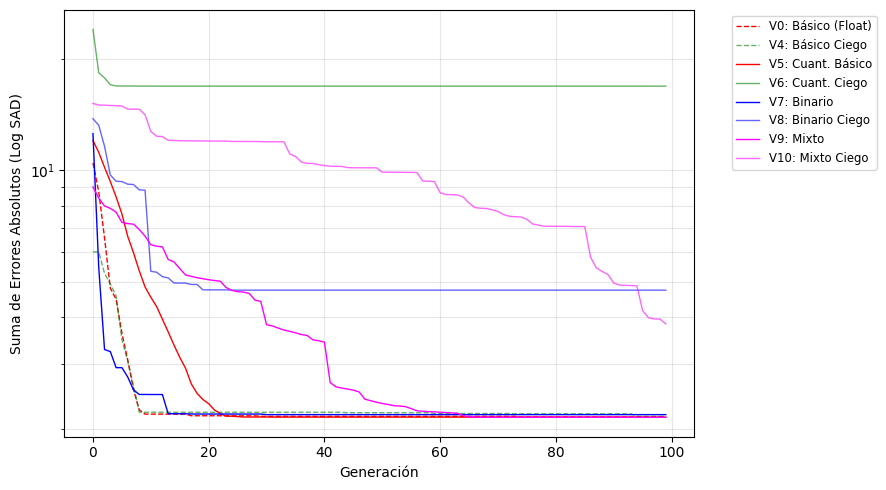

In [46]:
import time
import matplotlib.pyplot as plt
import numpy as np

# --- FUNCIÓN DE ERROR PARA LA TABLA ---
def calcular_error_tabla(res, real):
    return np.sqrt(np.mean((np.array(res) - np.array(real))**2))


# --- CONFIGURACIÓN ---
num_gen = 100
tam_pob = 42
real_vec = [A_real, sigma_G2_real, r_real]


#Padre inicial
# Generar ruido nuevo
_, muestras = RFI_MakeEnvelopeDataClassA(A_real, r_real, M, N, sigma_G2_real) 
# Procesar ECDF para esta muestra específica
p_log = 10 * np.log10(muestras**2 / 2)
mini, maxi = p_log.min(), p_log.max()
paso = (maxi - mini) / (N - 1)
histo, b_edge = np.histogram(p_log, N+1, (mini-2*paso, maxi+2*paso), density=True)
X_cdf = b_edge[:N+1]
CUM = np.cumsum(histo)
CDF = CUM/max(CUM)
ECDF = 1 - CDF
# Obtenemos la tupla de tu estimador y la convertimos al diccionario que pide el GA
A_e, S_e, r_e = est_inicial(muestras)
padre_dict = {'A': A_e, 'sigmag2': S_e, 'r': r_e}

def ejecutar_y_medir(func, *args):
    start = time.time()
    res, hist = func(*args)
    return res, hist, time.time() - start

print("Ejecutando comparativa completa de los 10 algoritmos...")

# Ejecución de todos los casos
r0, h0, t0 = ejecutar_y_medir(GA_ECDF_basico, ECDF, X_cdf, padre_dict, num_gen, tam_pob)
r4, h4, t4 = ejecutar_y_medir(GA_ECDF_basico_ciego, ECDF, X_cdf, num_gen, tam_pob)
r5, h5, t5 = ejecutar_y_medir(GA_ECDF_basico_cuantizado, ECDF, X_cdf, padre_dict, num_gen, tam_pob)
r6, h6, t6 = ejecutar_y_medir(GA_ECDF_ciego_cuantizado, ECDF, X_cdf, num_gen, tam_pob)
r7, h7, t7 = ejecutar_y_medir(GA_binario, ECDF, X_cdf, padre_dict, num_gen, tam_pob)
r8, h8, t8 = ejecutar_y_medir(GA_binario_ciego, ECDF, X_cdf, num_gen, tam_pob)
r9, h9, t9 = ejecutar_y_medir(GA_mixto, ECDF, X_cdf, padre_dict, num_gen, tam_pob)
r10, h10, t10 = ejecutar_y_medir(GA_mixto_ciego, ECDF, X_cdf, num_gen, tam_pob)

# --- TABLA DE RESULTADOS ---
print("\n" + "="*115)
header = f"{'ALGORITMO':<25} | {'A':<8} | {'sigmaG2':<8} | {'r (gamma)':<8} | {'ERR. PARÁM.':<12} | {'T(s)':<6}"
print(header)
print("-" * 115)
print(f"{'VALOR REAL (REF)':<25} | {real_vec[0]:<8.4f} | {real_vec[1]:<8.4f} | {real_vec[2]:<8.4f} | {'0.0000':<12} | ---")
print("-" * 115)

# Lista completa de los 10 resultados para procesar
lista_resultados = [
    ("V0: Básico Float", r0, h0, t0),
    ("V4: Básico Float Ciego", r4, h4, t4),
    ("V5: Básico Cuant. ", r5, h5, t5),
    ("V6: Básico Cuant. Ciego", r6, h6, t6),
    ("V7: Binario", r7, h7, t7),
    ("V8: Binario Ciego", r8, h8, t8),
    ("V9: Mixto", r9, h9, t9),
    ("V10: Mixto Ciego", r10, h10, t10)
    
]

for nombre, res, hist, t in lista_resultados:
    err_p = calcular_error_tabla(res, real_vec)
    print(f"{nombre:<25} | {res[0]:<8.5f} | {res[1]:<8.5f} | {res[2]:<8.5f} | {err_p:<12.8f} | {t:<6.2f}")
print("="*115)

# --- GRÁFICO DE CONVERGENCIA TOTAL (Escala Logarítmica) ---
plt.figure(figsize=(9, 5))

config_grafico = [
    (h0, 'red', '--', "V0: Básico (Float)"),
    (h4, 'green', '--', "V4: Básico Ciego"),
    (h5, 'red', '-', "V5: Cuant. Básico"),
    (h6, 'green', '-', "V6: Cuant. Ciego"),
    (h7, 'blue', '-', "V7: Binario"),
    (h8, 'blue', '-', "V8: Binario Ciego"),
    (h9, 'magenta', '-', "V9: Mixto"),
    (h10, 'magenta', '-', "V10: Mixto Ciego")
]

for h, col, ls, lab in config_grafico:
    # Ajustamos alpha para que los ciegos se diferencien un poco si se solapan
    a = 0.6 if "Ciego" in lab else 1.0
    plt.plot(h, color=col, linestyle=ls, label=lab, alpha=a, linewidth=1)

plt.yscale('log')
#plt.title('Comparativa de Convergencia: Error de Ajuste (SAD)', fontsize=11)
plt.xlabel('Generación')
plt.ylabel('Suma de Errores Absolutos (Log SAD)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# Ubicamos la leyenda fuera para no tapar las curvas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

## Simulaciones de Montecarlo

### Análisis de Robustez

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# --- 2. LISTA DE ALGORITMOS (Tu orden lógico) ---
algos = [
    (GA_ECDF_basico, "Padre", 'V0'),
    (GA_ECDF_basico_ciego, "Ciego", 'V4'),
    (GA_ECDF_basico_cuantizado, "Padre", 'V5'),
    (GA_ECDF_ciego_cuantizado, "Ciego", 'V6'),
    (GA_binario, "Padre", 'V7'),
    (GA_binario_ciego, "Ciego", 'V8'),
    (GA_mixto, "Padre", 'V9'),
    (GA_mixto_ciego, "Ciego", 'V10')
]

# --- CONFIGURACIÓN ---
n_ejecuciones = 50
num_gen = 100
tam_pob = 42
real_vec = np.array([A_real, sigma_G2_real, r_real])

# --- 3. BUCLE DE MONTE CARLO ---
resultados_mc = {a[2]: [] for a in algos}

for i in range(n_ejecuciones):
    # Generar ruido nuevo
    _, muestras = RFI_MakeEnvelopeDataClassA(A_real, r_real, M, N, sigma_G2_real)
    
    # Procesar ECDF para esta muestra específica
    p_log = 10 * np.log10(muestras**2 / 2)
    mini, maxi = p_log.min(), p_log.max()
    paso = (maxi - mini) / (N - 1)
    histo, b_edge = np.histogram(p_log, N+1, (mini-2*paso, maxi+2*paso), density=True)
    X_curr = b_edge[:N+1]
    ECDF_curr = 1 - (np.cumsum(histo) / np.sum(histo))
    
    # --- EL PUENTE ---
    # Obtenemos la tupla de tu estimador y la convertimos al diccionario que pide el GA
    A_e, S_e, r_e = est_inicial(muestras)
    padre_dinamico = {'A': A_e, 'sigmag2': S_e, 'r': r_e}
    
    print(f"Ejecución {i+1:02}/{n_ejecuciones}...", end="\r")

    for func, tipo, nombre in algos:
        # Aquí el código sabe cuántos parámetros pasar
        if tipo == "Padre":
            res, _ = func(ECDF_curr, X_curr, padre_dinamico, num_gen, tam_pob)
        else:
            res, _ = func(ECDF_curr, X_curr, num_gen, tam_pob)
        
        err = np.mean((np.array(res) - real_vec)**2)
        resultados_mc[nombre].append(err)

Gen 0: Error=10.048290 | A=0.208, s2=0.123, r=0.054
Gen 10: Error=2.526684 | A=0.255, s2=0.097, r=0.052
Gen 20: Error=2.526684 | A=0.255, s2=0.097, r=0.052
Gen 30: Error=2.526684 | A=0.255, s2=0.097, r=0.052
Gen 40: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 50: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 60: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 70: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 80: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 90: Error=2.525892 | A=0.256, s2=0.096, r=0.052
Gen 000: Error=30.873145 | A=0.907
Gen 010: Error=20.998838 | A=0.653
Gen 020: Error=18.608085 | A=0.567
Gen 030: Error=15.713177 | A=0.477
Gen 040: Error=10.163081 | A=0.356
Gen 050: Error=2.726567 | A=0.256
Gen 060: Error=2.527884 | A=0.256
Gen 070: Error=2.527884 | A=0.256
Gen 080: Error=2.527884 | A=0.256
Gen 090: Error=2.527884 | A=0.256
Gen 099: Error=2.527884 | A=0.256
Gen 00 | Mejor Err (Binario): 13.51738501
Gen 10 | Mejor Err (Binario): 10.02581859
Gen 20 | Mejor Er

#### Graficar


ALGORITMO                 | MSE (Promedio)     | VARIANZA       
-------------------------------------------------------------------------------------
V0                        | 0.0002260723       | 0.0000000784   
V4                        | 0.0002236505       | 0.0000000768   
V5                        | 0.0002267044       | 0.0000000805   
V6                        | 0.0063607882       | 0.0004041804   
V7                        | 0.0005742906       | 0.0000006695   
V8                        | 0.0010123043       | 0.0000099133   
V9                        | 0.0002259449       | 0.0000000791   
V10                       | 0.0002588209       | 0.0000001189   


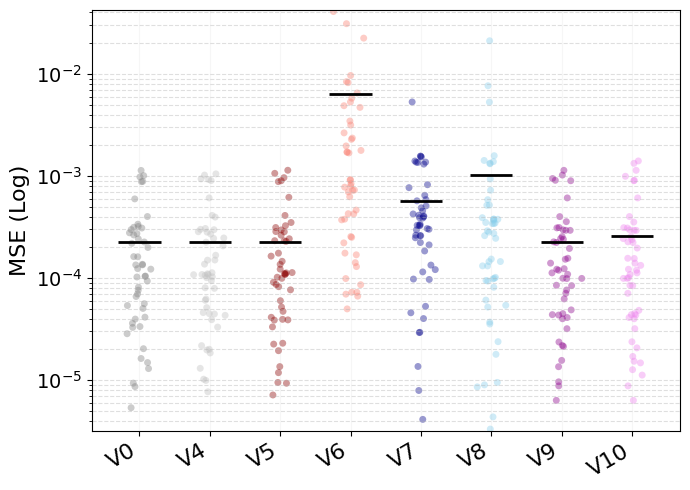

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# --- TABLA ESTADÍSTICA ---
print("\n" + "="*85)
print(f"{'ALGORITMO':<25} | {'MSE (Promedio)':<18} | {'VARIANZA':<15}")
print("-" * 85)

todos_los_errores = [] # Para calcular los límites del gráfico después

for _, _, nombre in algos:
    errores = np.array(resultados_mc[nombre])
    mse_final = np.mean(errores) 
    varianza_final = np.var(errores)
    print(f"{nombre:<25} | {mse_final:<18.10f} | {varianza_final:<15.10f}")
    todos_los_errores.extend(errores)

print("="*85)

# --- GRÁFICO DE DISPERSIÓN LOGARÍTMICO ---
plt.figure(figsize=(7, 5))

colores_mc = ['grey', 'silver', 'darkred', 'salmon', 'darkblue', 'skyblue', 'darkmagenta', 'violet']

for i, (_, _, nombre) in enumerate(algos):
    errores = np.array(resultados_mc[nombre])
    # Jitter para dispersión horizontal
    x = np.random.normal(i + 1, 0.08, size=len(errores))
    
    # Scatter plot
    plt.scatter(x, errores, alpha=0.4, color=colores_mc[i], s=25, edgecolors='none')
    
    # Línea horizontal del promedio (en escala log, la media aritmética sigue siendo válida)
    plt.hlines(np.mean(errores), i + 0.7, i + 1.3, colors='black', lw=2, zorder=5)

# 1. Configurar ESCALA LOGARÍTMICA
plt.yscale('log')

# 2. LIMITAR A PUNTOS DE INTERÉS
# Filtramos valores extremos (outliers) para que el gráfico no se vea vacío
# Usamos el percentil 1 y 99 para asegurar que vemos el "grueso" de los datos
datos_limpios = np.array(todos_los_errores)
datos_limpios = datos_limpios[datos_limpios > 0] # Evitar errores con log(0)
if len(datos_limpios) > 0:
    y_min = np.percentile(datos_limpios, 1) / 2  # Un poco por debajo del mínimo
    y_max = np.percentile(datos_limpios, 99) * 2 # Un poco por encima del máximo
    plt.ylim(y_min, y_max)

# Formateo estético
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(range(1, len(algos) + 1), [a[2] for a in algos], rotation=30, ha='right',fontsize=16)
plt.ylabel('MSE (Log)', fontsize=16)
#plt.title(f'Análisis de Monte Carlo: Robustez ({n_ejecuciones} corridas)')

# Grilla adaptada a escala logarítmica
plt.grid(True, which="both", axis='y', ls='--', alpha=0.4)
plt.grid(True, which="major", axis='x', ls='-', alpha=0.1)

plt.tight_layout()
plt.show()

### Analissis convergencia para algoritmos Mixtos, siguiendo Montecarlo

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN ---
n_corridas = 500
num_gen = 100
tam_pob = 40
A_real = 0.25   # Parametro A del Ruido Clase A
sigma_G2_real = 0.1  # # Potencia de Ruido Gaussiano o Background Noise
r_real = 0.050    # Parametro gamma del Ruido de Clase A
real_vec = np.array([A_real, sigma_G2_real, r_real])
M       =  10      # Cantidad de terminos a ser considerados en la sumatoria de la pdf de Ruido de Clase A
N       = 512      # Cantidad de muestras a ser generadas

# Contenedores para los historiales de error (SAD)
historiales_v9 = []  # Mixto con Padre
historiales_v10 = [] # Mixto Ciego

print("Iniciando simulacion de convergencia (50 corridas)...")

for i in range(n_corridas):
    # A. Generar ruido nuevo
    _, muestras = RFI_MakeEnvelopeDataClassA(A_real, r_real, M, N, sigma_G2_real)
    
    # B. Procesar ECDF
    p_log = 10 * np.log10(muestras**2 / 2)
    mini, maxi = p_log.min(), p_log.max()
    paso = (maxi - mini) / (N - 1)
    histo, b_edge = np.histogram(p_log, N+1, (mini-2*paso, maxi+2*paso), density=True)
    X_curr = b_edge[:N+1]
    ECDF_curr = 1 - (np.cumsum(histo) / np.sum(histo))
    
    # C. Generar Padre Dinámico con el estimador
    Ae, Se, re = est_inicial(muestras)
    p_dict = {'A': Ae, 'sigmag2': Se, 'r': re}
      
    
    # V9: Mixto con Padre Dinámico
    _, h9 = GA_mixto(ECDF_curr, X_curr, p_dict, num_gen, tam_pob)
    historiales_v9.append(h9)
        
    # V10: Mixto Ciego
    _, h10 = GA_mixto_ciego(ECDF_curr, X_curr, num_gen, tam_pob)
    historiales_v10.append(h10)
        
    print(f"Progreso: {i+1:02}/{n_corridas}...", end="\r")

# Convertir a matrices para promediar
h9_mat = np.array(historiales_v9)
h10_mat = np.array(historiales_v10)

Iniciando simulacion de convergencia (50 corridas)...


#### Gráficos

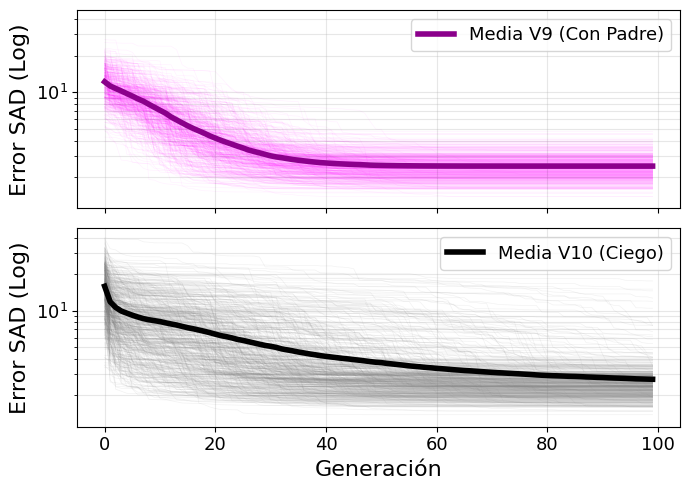

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Calculamos límites globales
y_min = min(h9_mat.min(), h10_mat.min())
y_max = max(h9_mat.max(), h10_mat.max())

# --- AJUSTE DE FIGURA: 2 filas, 1 columna. Tamaño total (7, 5) ---
# sharex=True hace que compartan el eje X, sharey=True comparten el eje Y
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True, sharey=True)

# --- PANEL 1 (ARRIBA): V9 MIXTO CON PADRE ---
for fila in h9_mat:
    ax1.plot(fila, color='magenta', alpha=0.05, linewidth=0.5)

media9 = np.mean(h9_mat, axis=0)
ax1.plot(media9, color='darkmagenta', linewidth=4, label='Media V9 (Con Padre)')

ax1.set_yscale('log')
ax1.set_ylim(y_min * 0.8, y_max * 1.2)
ax1.set_ylabel('Error SAD (Log)', fontsize=16) 
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=13, loc='upper right')

# Agrandar números de las escalas (ticks)
ax1.tick_params(axis='both', which='major', labelsize=13)

# --- PANEL 2 (ABAJO): V10 MIXTO CIEGO ---
for fila in h10_mat:
    ax2.plot(fila, color='grey', alpha=0.1, linewidth=0.5)

media10 = np.mean(h10_mat, axis=0)
ax2.plot(media10, color='black', linewidth=4, label='Media V10 (Ciego)')

ax2.set_yscale('log')
ax2.set_xlabel('Generación', fontsize=16) # La etiqueta X va solo en el de abajo
ax2.set_ylabel('Error SAD (Log)', fontsize=16)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(fontsize=13, loc='upper right')

# Agrandar números de las escalas (ticks)
ax2.tick_params(axis='both', which='major', labelsize=13)

# tight_layout evita que los textos o ejes se superpongan entre los dos paneles
plt.tight_layout()
plt.show()

## Búsqueda por grilla para algortimo mixto con parámetros desacoplados

### BÚSQUEDA POR GRILLA

In [ ]:
import itertools
import sys
import numpy as np

#Búsqueda de grilla + Monte Carlo para el GA con parámetros desacoplados.

def buscar_parametros_independientes_montecarlo(real_vec, n_corridas=10):
    """
    Busqueda de grilla + Monte Carlo para el GA con parámetros desacoplados.
    Se fija p_creep y p_mut para explorar la relación entre BIN y SHUF.
    """
    
    # 1. Definimos los rangos de búsqueda
    # MUT y CREEP se quedan en valores de alta estabilidad
    r_mut  = [0.2, 0.25]          # Fijamos la mutación en el punto óptimo detectado
    r_creep = [0.2, 0.25]         # Fijamos el ajuste fino en el valor de mayor precisión
    bits_A=[3, 4, 5]
    bits_S=[2, 3]
    bits_G= [3, 4]
    
    # Variamos BIN y SHUF de forma independiente
    # Nota: si la suma es < 1.0, el resto son CLONES (estabilidad)
    r_bin  = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    r_shuf = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    
    print("\n" + "="*120)
    print(f"{'MUT':<6} | {'BIN':<6} | {'SHUF':<6} | {'CREEP':<6} |  {'bits_A'}:{'bits_S'}:{'bits_G'} |{'CLONES':<8} | {'A_err_p':<10} | {'RMSE_PROM'}")
    print("-" * 120)

    mejor_err_global = float('inf')
    mejor_set = {}

    # La grilla ahora es ortogonal: cada variable es independiente
    for m, pc, pb, ps, bits_A, bits_S, bits_G in itertools.product(r_mut, r_creep, r_bin, r_shuf, bits_A, bits_S, bits_G):
        
        # Calculamos cuánto "Fondo de Copias" (elitismo) queda disponible
        p_clones = 1.0 - (pb + ps + pc)
        if p_clones < 0: continue # Evitamos combinaciones imposibles (suma > 1)

        errores_A, rmises = [], []

        for j in range(n_corridas):
            # --- Generación de datos y ECDF (Monte Carlo) ---
            _, m_batch = RFI_MakeEnvelopeDataClassA(real_vec[0], real_vec[2], M, N, real_vec[1])
            p_log = 10 * np.log10(m_batch**2 / 2)
            histo, b_edge = np.histogram(p_log, N+1, (p_log.min(), p_log.max()), density=True)
            X_batch = b_edge[:N+1]
            ECDF_batch = 1 - (np.cumsum(histo) / np.sum(histo))
            
            # --- Estimador Inicial (Puente) ---
            Ae, Se, re = est_inicial(m_batch)
            p_ini = {'A': Ae, 'sigmag2': Se, 'r': re}

            # --- Ejecutar NUEVO GA (Ajuste Fino Independiente) ---
            # Se pasan los parámetros tal cual se definieron en la grilla            
            res, _ = GA_mixto_parametros_desacoplados(
                ECDF_batch, X_batch, p_ini, 
                generaciones=100, 
                tam_poblacion=42,
                mutacion=m, 
                p_bin=pb, 
                p_shuf=ps, 
                p_creep=pc,
                bits_A= bits_A, 
                bits_S=bits_S, 
                bits_G=bits_G
            )
            
            # --- Acumular Errores ---
            errores_A.append(abs(res[0] - real_vec[0]))
            rmises.append(np.sqrt(np.mean((np.array(res) - real_vec)**2)))

        # Promediamos Monte Carlo
        A_p = np.mean(errores_A)
        rmse_p = np.mean(rmises)

        # Imprimimos incluyendo la columna de CLONES para ver la estabilidad
        bit_str = f"{bits_A}:{bits_S}:{bits_G}"
        print(f"{m:<6.2f} | {pb:<6.2f} | {ps:<6.2f} | {pc:<6.2f} | {bit_str:<21} | {p_clones:<8.2f} | {A_p:<10.6f} | {rmse_p:.8f}")
        sys.stdout.flush()

        if rmse_p < mejor_err_global:
            mejor_err_global = rmse_p
            # Arreglo del DICCIONARIO (tenías bits_A repetido y bits_S mal asignado)
            mejor_set = {
                'm': m, 'pb': pb, 'ps': ps, 'pc': pc, 
                'bits_A': bits_A, 'bits_S': bits_S, 'bits_G': bits_G,
                'clones': p_clones, 'rmse': rmse_p
            }

    print("="*140)
    return mejor_set

In [76]:
# Valores reales
real_vec = np.array([A_real, sigma_G2_real, r_real])

# Iniciamos la búsqueda exhaustiva basada en promedios de Monte Carlo
# Nota: Esto tardará bastante porque hace (Combinaciones * 50) ejecuciones de GA
best_config = buscar_parametros_independientes_montecarlo(real_vec, n_corridas=50)

print(f"\n---> MEJOR CONFIGURACIÓN BASADA EN PROMEDIO DE MONTE CARLO:")
print(best_config)


MUT    | BIN    | SHUF   | CREEP  |  bits_A:bits_S:bits_G |CLONES   | A_err_p    | RMSE_PROM
------------------------------------------------------------------------------------------------------------------------
0.20   | 0.00   | 0.00   | 0.20   | 3:2:3                | 0.80     | 0.030469   | 0.02477865
0.20   | 0.00   | 0.00   | 0.20   | 3:2:4                | 0.80     | 0.031525   | 0.02657327
0.20   | 0.00   | 0.00   | 0.20   | 3:3:3                | 0.80     | 0.035018   | 0.02770512
0.20   | 0.00   | 0.00   | 0.20   | 3:3:4                | 0.80     | 0.039390   | 0.02950497
0.20   | 0.00   | 0.00   | 0.20   | 4:2:3                | 0.80     | 0.033400   | 0.02690101
0.20   | 0.00   | 0.00   | 0.20   | 4:2:4                | 0.80     | 0.035186   | 0.02734244
0.20   | 0.00   | 0.00   | 0.20   | 4:3:3                | 0.80     | 0.040987   | 0.03080338
0.20   | 0.00   | 0.00   | 0.20   | 4:3:4                | 0.80     | 0.033115   | 0.02681185
0.20   | 0.00   | 0.00   | 0.20  

### Simulación mixto para paramteros hallados + comprativa coon ES

Iniciando Monte Carlo: GA Mixto Guiado vs Estimador Simple...
Config: BIN=0, SHUF=0.4, CREEP=0.3 | Gen=60
-------------------------------------------------------------------------------------
Iteración 05/50 | MSE Simple: 0.002380 | MSE GA Guiado: 0.000228
Iteración 10/50 | MSE Simple: 0.004205 | MSE GA Guiado: 0.000971
Iteración 15/50 | MSE Simple: 0.002898 | MSE GA Guiado: 0.001542
Iteración 20/50 | MSE Simple: 0.002303 | MSE GA Guiado: 0.001549
Iteración 25/50 | MSE Simple: 0.003057 | MSE GA Guiado: 0.001564
Iteración 30/50 | MSE Simple: 0.002863 | MSE GA Guiado: 0.001564
Iteración 35/50 | MSE Simple: 0.002002 | MSE GA Guiado: 0.000306
Iteración 40/50 | MSE Simple: 0.002662 | MSE GA Guiado: 0.001564
Iteración 45/50 | MSE Simple: 0.004642 | MSE GA Guiado: 0.000221
Iteración 50/50 | MSE Simple: 0.003279 | MSE GA Guiado: 0.001552

                      TABLA DE ERRORES CUADRÁTICOS MEDIOS (MSE)                      
Parámetro       | Est. Simple        | GA Guiado (Todos)  | GA Guiado (

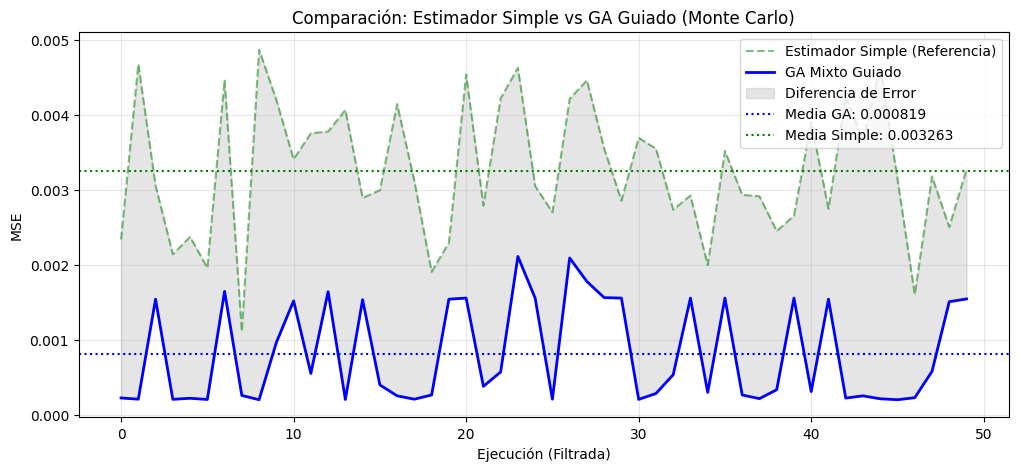

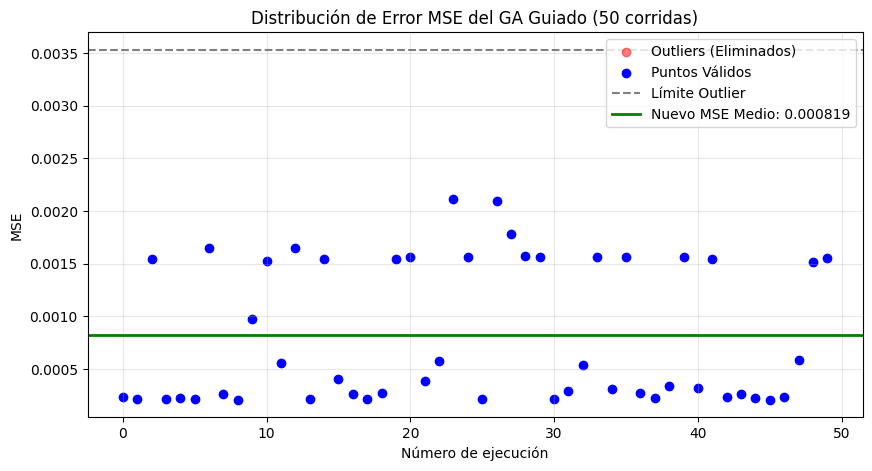


ESTIMACIONES FINALES GA GUIADO (PROMEDIO FILTRADO):
A:        0.2193 (±0.0276) | Real: 0.25
Sigma_G2: 0.1250 (±0.0000) | Real: 0.1
Gamma(r): 0.0589 (±0.0069) | Real: 0.05


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# --- 1. CONFIGURACIÓN FINAL ---
n_ejecuciones = 50
num_gen = 60       
tam_pob = 42
real_vec = np.array([A_real, sigma_G2_real, r_real])

# Parámetros óptimos que hallaste
p_opt = {
    'm': 0.20,      # mutacion
    'pb': 0,        # p_bin
    'ps': 0.4,      # p_shuf
    'pc': 0.3,      # p_creep
    'bitsA': 5,     # bits_A
    'bitsS': 3,     # bits_S
    'bitsG': 3      # bits_G
}

# Listas para GA Guiado
errores_mse_ga = []
errores_param_ga = [] 
resultados_ga = []

# Listas para Estimador Simple (Referencia)
errores_mse_simple = []
errores_param_simple = [] 
resultados_simple = []

print(f"Iniciando Monte Carlo: GA Mixto Guiado vs Estimador Simple...")
print(f"Config: BIN={p_opt['pb']}, SHUF={p_opt['ps']}, CREEP={p_opt['pc']} | Gen={num_gen}")
print("-" * 85)

# --- 2. BUCLE MONTE CARLO ---
for i in range(n_ejecuciones):
    # Generar ruido nuevo en cada iteración
    _, muestras = RFI_MakeEnvelopeDataClassA(A_real, r_real, M, N, sigma_G2_real)
    
    # --- A. ESTIMADOR SIMPLE (Referencia y Puente) ---
    Ae, Se, re = est_inicial(muestras)
    res_s = np.array([Ae, Se, re])
    p_ini = {'A': Ae, 'sigmag2': Se, 'r': re} # Diccionario para el GA Guiado
    
    # Cálculo MSE Simple
    err_param_s = (res_s - real_vec)**2 
    err_s = np.mean(err_param_s)        
    
    resultados_simple.append(res_s)
    errores_mse_simple.append(err_s)
    errores_param_simple.append(err_param_s)
    
    # --- B. PROCESAMIENTO ECDF PARA GA ---
    p_log = 10 * np.log10(muestras**2 / 2)
    mini, maxi = p_log.min(), p_log.max()
    paso = (maxi - mini) / (N - 1)
    histo, b_edge = np.histogram(p_log, N+1, (mini-2*paso, maxi+2*paso), density=True)
    X_curr = b_edge[:N+1]
    ECDF_curr = 1 - (np.cumsum(histo) / np.sum(histo))
            
    # --- C. EJECUCIÓN DEL GA MIXTO GUIADO ---
    res_ga, _ = GA_mixto_parametros_desacoplados(
        ECDF_curr, 
        X_curr, 
        padre_inicial=p_ini,
        generaciones=num_gen, 
        tam_poblacion=tam_pob,
        mutacion=p_opt['m'], 
        p_bin=p_opt['pb'], 
        p_shuf=p_opt['ps'], 
        p_creep=p_opt['pc'],
        bits_A=p_opt['bitsA'], 
        bits_S=p_opt['bitsS'], 
        bits_G=p_opt['bitsG']
    )
    
    # Cálculo MSE GA Guiado
    err_param_ga = (np.array(res_ga) - real_vec)**2 
    err_ga = np.mean(err_param_ga)                  
    
    resultados_ga.append(res_ga)
    errores_mse_ga.append(err_ga)
    errores_param_ga.append(err_param_ga)
    
    # Monitor de progreso
    if (i+1) % 5 == 0:
        print(f"Iteración {i+1:02}/{n_ejecuciones} | MSE Simple: {err_s:.6f} | MSE GA Guiado: {err_ga:.6f}")
    sys.stdout.flush()

# --- 3. CONVERSIÓN A ARRAYS ---
errores_mse_ga = np.array(errores_mse_ga)
errores_mse_simple = np.array(errores_mse_simple)
errores_param_ga = np.array(errores_param_ga) 
errores_param_simple = np.array(errores_param_simple)
resultados_ga = np.array(resultados_ga)
resultados_simple = np.array(resultados_simple)

# --- 4. FILTRADO DE OUTLIERS (Criterio IQR sobre MSE global del GA) ---
Q1 = np.percentile(errores_mse_ga, 25)
Q3 = np.percentile(errores_mse_ga, 75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

# Máscara booleana para quedarnos con lo que está por debajo del límite
mask = errores_mse_ga <= limite_sup

# Aplicamos el filtro
errores_mse_ga_f = errores_mse_ga[mask]
errores_param_ga_f = errores_param_ga[mask]
resultados_ga_f = resultados_ga[mask]
sim_f = errores_mse_simple[mask] # Estimador simple correspondiente a las corridas válidas

# --- 5. TABLA DE RESULTADOS ---
mean_err_param_s = np.mean(errores_param_simple, axis=0)
mean_err_param_ga = np.mean(errores_param_ga, axis=0)
mean_mse_s = np.mean(errores_mse_simple)
mean_mse_ga = np.mean(errores_mse_ga)

mean_err_param_ga_f = np.mean(errores_param_ga_f, axis=0)
mean_mse_ga_f = np.mean(errores_mse_ga_f)

print("\n" + "="*85)
print(f"{'TABLA DE ERRORES CUADRÁTICOS MEDIOS (MSE)':^85}")
print("="*85)
print(f"{'Parámetro':<15} | {'Est. Simple':<18} | {'GA Guiado (Todos)':<18} | {'GA Guiado (Filt)':<18}")
print("-" * 85)
print(f"{'A':<15} | {mean_err_param_s[0]:<18.8f} | {mean_err_param_ga[0]:<18.8f} | {mean_err_param_ga_f[0]:<18.8f}")
print(f"{'sigma_G^2':<15} | {mean_err_param_s[1]:<18.8f} | {mean_err_param_ga[1]:<18.8f} | {mean_err_param_ga_f[1]:<18.8f}")
print(f"{'Gamma (r)':<15} | {mean_err_param_s[2]:<18.8f} | {mean_err_param_ga[2]:<18.8f} | {mean_err_param_ga_f[2]:<18.8f}")
print("-" * 85)
print(f"{'ERROR TOTAL':<15} | {mean_mse_s:<18.8f} | {mean_mse_ga:<18.8f} | {mean_mse_ga_f:<18.8f}")
print("="*85)
print(f"Ejecuciones descartadas por outliers (GA): {n_ejecuciones - len(errores_mse_ga_f)} de {n_ejecuciones}")
print("-" * 85)

# --- 6. GRÁFICO COMPARATIVO CON SOMBRA (FILTRADO) ---
plt.figure(figsize=(12, 5))
x = np.arange(len(errores_mse_ga_f)) 

plt.plot(sim_f, 'g--', alpha=0.5, label='Estimador Simple (Referencia)')
plt.plot(errores_mse_ga_f, 'b-', linewidth=2, label='GA Mixto Guiado')

# Sombreado gris
plt.fill_between(x, errores_mse_ga_f, sim_f, color='gray', alpha=0.2, label='Diferencia de Error')

media_sim_f = np.mean(sim_f)

plt.axhline(y=mean_mse_ga_f, color='blue', linestyle=':', label=f'Media GA: {mean_mse_ga_f:.6f}')
plt.axhline(y=media_sim_f, color='green', linestyle=':', label=f'Media Simple: {media_sim_f:.6f}')

plt.title('Comparación: Estimador Simple vs GA Guiado (Monte Carlo)')
plt.ylabel('MSE')
plt.xlabel('Ejecución (Filtrada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 7. GRÁFICO DE DISPERSIÓN DE OUTLIERS ---
plt.figure(figsize=(10, 5))
indices = np.arange(n_ejecuciones)

plt.scatter(indices[~mask], errores_mse_ga[~mask], color='red', alpha=0.5, label='Outliers (Eliminados)')
plt.scatter(indices[mask], errores_mse_ga_f, color='blue', label='Puntos Válidos')

plt.axhline(y=limite_sup, color='gray', linestyle='--', label='Límite Outlier')
plt.axhline(y=mean_mse_ga_f, color='green', linewidth=2, label=f'Nuevo MSE Medio: {mean_mse_ga_f:.6f}')

plt.title(f'Distribución de Error MSE del GA Guiado ({n_ejecuciones} corridas)')
plt.xlabel('Número de ejecución')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 8. ESTADÍSTICAS FINALES DE LOS PARÁMETROS ---
promedios_ga = np.mean(resultados_ga_f, axis=0)
stds_ga = np.std(resultados_ga_f, axis=0)

print("\n" + "="*70)
print(f"ESTIMACIONES FINALES GA GUIADO (PROMEDIO FILTRADO):")
print(f"A:        {promedios_ga[0]:.4f} (±{stds_ga[0]:.4f}) | Real: {real_vec[0]}")
print(f"Sigma_G2: {promedios_ga[1]:.4f} (±{stds_ga[1]:.4f}) | Real: {real_vec[1]}")
print(f"Gamma(r): {promedios_ga[2]:.4f} (±{stds_ga[2]:.4f}) | Real: {real_vec[2]}")
print("="*70)

#### Gráficos

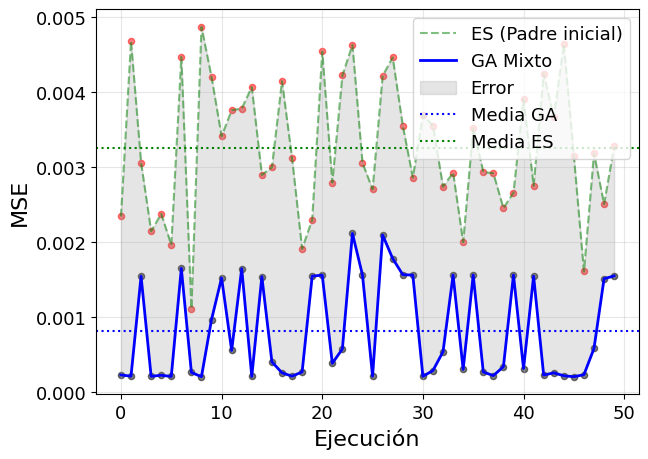

In [76]:
# --- 6. GRÁFICO COMPARATIVO CON SOMBRA (FILTRADO) ---
plt.figure(figsize=(7, 5))
x = np.arange(len(errores_mse_ga_f)) 


plt.plot(sim_f, 'g--', alpha=0.5, label='ES (Padre inicial)')
plt.scatter(x, sim_f, color='red', s=20, alpha=0.5)
plt.plot(errores_mse_ga_f, 'b-', linewidth=2, label='GA Mixto')
plt.scatter(x, errores_mse_ga_f, color='black', s=20, alpha=0.5)

# Sombreado gris
plt.fill_between(x, errores_mse_ga_f, sim_f, color='gray', alpha=0.2, label='Error')

media_sim_f = np.mean(sim_f)

plt.axhline(y=mean_mse_ga_f, color='blue', linestyle=':', label=f'Media GA')
plt.axhline(y=media_sim_f, color='green', linestyle=':', label=f'Media ES')

#plt.title('Comparación: Estimador Simple vs GA Guiado (Monte Carlo)')
plt.ylabel('MSE',fontsize=16)
plt.xlabel('Ejecución',fontsize=16)
plt.legend(fontsize=13, loc='upper right')
plt.grid(True, alpha=0.3)

# Agrandar números de las escalas (ticks)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.show()


## Búsqueda por grilla para algortimo mixto ciego con parámetros desacoplados

### BÚSQUEDA POR GRILLA

In [71]:
import itertools
import sys
import numpy as np

#Búsqueda de grilla + Monte Carlo para el GA con parámetros desacoplados.

def buscar_parametros_independientes_montecarlo_ciego(real_vec, n_corridas=10):
    """
    Busqueda de grilla + Monte Carlo para el GA con parámetros desacoplados.
    Se fija p_creep y p_mut para explorar la relación entre BIN y SHUF.
    """
    
    # 1. Definimos los rangos de búsqueda
    # MUT y CREEP se quedan en valores de alta estabilidad
    #r_mut  = [0.20]          # Fijamos la mutación en el punto óptimo detectado
    #r_creep = [0.20]         # Fijamos el ajuste fino en el valor de mayor precisión
    
    # Variamos BIN y SHUF de forma independiente
    # Nota: si la suma es < 1.0, el resto son CLONES (estabilidad)
    bits_A=3
    bits_S=3
    bits_G=3
    r_bin  = [0.0, 0.1, 0.2, 0.3, 0.4]
    r_shuf = [0.0, 0.1, 0.2, 0.3, 0.4]
    r_mut  = [0.20, 0.25]          # Fijamos la mutación en el punto óptimo detectado
    r_creep = [0.20, 0.25]    
    
    print("\n" + "="*120)
    print(f"{'MUT':<6} | {'BIN':<6} | {'SHUF':<6} | {'CREEP':<6} | {'CLONES':<8} | {'A_err_p':<10} | {'RMSE_PROM'}")
    print("-" * 120)

    mejor_err_global = float('inf')
    mejor_set = {}

    # La grilla ahora es ortogonal: cada variable es independiente
    for m, pc, pb, ps in itertools.product(r_mut, r_creep, r_bin, r_shuf):
        
        # Calculamos cuánto "Fondo de Copias" (elitismo) queda disponible
        p_clones = 1.0 - (pb + ps + pc)
        if p_clones < 0: continue # Evitamos combinaciones imposibles (suma > 1)

        errores_A, rmises = [], []

        for j in range(n_corridas):
            # --- Generación de datos y ECDF (Monte Carlo) ---
            _, m_batch = RFI_MakeEnvelopeDataClassA(real_vec[0], real_vec[2], M, N, real_vec[1])
            p_log = 10 * np.log10(m_batch**2 / 2)
            histo, b_edge = np.histogram(p_log, N+1, (p_log.min(), p_log.max()), density=True)
            X_batch = b_edge[:N+1]
            ECDF_batch = 1 - (np.cumsum(histo) / np.sum(histo))
            
            #     
            # --- Ejecutar NUEVO GA (Ajuste Fino Independiente) ---
            # Se pasan los parámetros tal cual se definieron en la grilla

            
            res, _ = GA_mixto_ciego_parametros_desacoplados(
                ECDF_batch, X_batch, 
                generaciones=100, 
                tam_poblacion=44,
                mutacion=m, 
                p_bin=pb, 
                p_shuf=ps, 
                p_creep=pc,bits_A= bits_A, 
                bits_S=bits_S, 
                bits_G=bits_G
            )
            
            # --- Acumular Errores ---
            errores_A.append(abs(res[0] - real_vec[0]))
            rmises.append(np.sqrt(np.mean((np.array(res) - real_vec)**2)))

        # Promediamos Monte Carlo
        A_p = np.mean(errores_A)
        rmse_p = np.mean(rmises)

        # Imprimimos incluyendo la columna de CLONES para ver la estabilidad
        print(f"{m:<6.2f} | {pb:<6.2f} | {ps:<6.2f} | {pc:<6.2f} | {p_clones:<8.2f} | {A_p:<10.6f} | {rmse_p:.8f}")
        sys.stdout.flush()

        if rmse_p < mejor_err_global:
            mejor_err_global = rmse_p
            mejor_set = {'m': m, 'pb': pb, 'ps': ps, 'pc': pc, 'clones': p_clones, 'rmse': rmse_p}

    print("="*120)
    return mejor_set

In [72]:
# Valores reales
real_vec = np.array([A_real, sigma_G2_real, r_real])

# Iniciamos la búsqueda exhaustiva basada en promedios de Monte Carlo
# Nota: Esto tardará bastante porque hace (Combinaciones * 50) ejecuciones de GA
best_config = buscar_parametros_independientes_montecarlo_ciego(real_vec, n_corridas=10)

print(f"\n---> MEJOR CONFIGURACIÓN BASADA EN PROMEDIO DE MONTE CARLO:")
print(best_config)


MUT    | BIN    | SHUF   | CREEP  | CLONES   | A_err_p    | RMSE_PROM
------------------------------------------------------------------------------------------------------------------------
0.20   | 0.00   | 0.00   | 0.20   | 0.80     | 0.094156   | 0.05995578
0.20   | 0.00   | 0.10   | 0.20   | 0.70     | 0.132401   | 0.08337135
0.20   | 0.00   | 0.20   | 0.20   | 0.60     | 0.038977   | 0.02852077
0.20   | 0.00   | 0.30   | 0.20   | 0.50     | 0.087128   | 0.05640142
0.20   | 0.00   | 0.40   | 0.20   | 0.40     | 0.052798   | 0.03653374
0.20   | 0.10   | 0.00   | 0.20   | 0.70     | 0.018790   | 0.01416592
0.20   | 0.10   | 0.10   | 0.20   | 0.60     | 0.054984   | 0.03529109
0.20   | 0.10   | 0.20   | 0.20   | 0.50     | 0.046890   | 0.03166088
0.20   | 0.10   | 0.30   | 0.20   | 0.40     | 0.082425   | 0.05165682
0.20   | 0.10   | 0.40   | 0.20   | 0.30     | 0.044540   | 0.03089726
0.20   | 0.20   | 0.00   | 0.20   | 0.60     | 0.075391   | 0.04864722
0.20   | 0.20   | 0.10   | 

### SIMULACIÓN MIXTO CIEGO PARA PARAMETROS HALLADOS

#### Comparativa entre MSE del estimador simple y GA mixto ciego

In [155]:
import numpy as np
import sys

# --- 1. CONFIGURACIÓN ---
n_ejecuciones = 50
num_gen = 120
tam_pob = 44

# Vector real [A, sigma_G2, r] -> Asegurate de tener definidas estas variables antes
real_vec = np.array([A_real, sigma_G2_real, r_real]) 

# Parámetros óptimos que hallaste (Cargalos aquí)
p_opt = {
    'm': 0.2,      # mutacion
    'pb': 0.2,     # p_bin
    'ps': 0.1,     # p_shuf
    'pc': 0.25,     # p_creep
    'bits': 3       # bits_A, S, G
}

# Listas para GA
errores_mse_ga = []
errores_param_ga = [] 
resultados_ga = []

# Listas para Estimador Simple (La comparación)
errores_mse_simple = []
errores_param_simple = [] 
resultados_simple = []

print(f"Iniciando Monte Carlo: GA Ciego vs Estimador Simple...")
print("-" * 85)

# --- 2. BUCLE MONTE CARLO ---
for i in range(n_ejecuciones):
    # Generar ruido nuevo
    _, muestras = RFI_MakeEnvelopeDataClassA(A_real, r_real, M, N, sigma_G2_real)
    
    # --- A. ESTIMADOR SIMPLE (Referencia) ---
    Ae, Se, re = est_inicial(muestras)
    res_s = np.array([Ae, Se, re])
    
    err_param_s = (res_s - real_vec)**2 
    err_s = np.mean(err_param_s)        
    
    resultados_simple.append(res_s)
    errores_mse_simple.append(err_s)
    errores_param_simple.append(err_param_s)
    
    # --- B. PROCESAMIENTO ECDF PARA GA ---
    p_log = 10 * np.log10(muestras**2 / 2)
    mini, maxi = p_log.min(), p_log.max()
    paso = (maxi - mini) / (N - 1)
    histo, b_edge = np.histogram(p_log, N+1, (mini-2*paso, maxi+2*paso), density=True)
    X_curr, ECDF_curr = b_edge[:N+1], 1 - (np.cumsum(histo) / np.sum(histo))
    
    # --- C. EJECUCIÓN DEL GA CIEGO ---
    res_ga, _ = GA_mixto_ciego_parametros_desacoplados(
        ECDF_curr, X_curr, generaciones=num_gen, tam_poblacion=tam_pob,
        mutacion=p_opt['m'], p_bin=p_opt['pb'], p_shuf=p_opt['ps'], 
        p_creep=p_opt['pc'], bits_A=p_opt['bits'], bits_S=p_opt['bits'], bits_G=p_opt['bits']
    )
    
    err_param_ga = (np.array(res_ga) - real_vec)**2 
    err_ga = np.mean(err_param_ga)                  
    
    resultados_ga.append(res_ga)
    errores_mse_ga.append(err_ga)
    errores_param_ga.append(err_param_ga)
    
    if (i+1) % 5 == 0:
        print(f"It {i+1:02} | MSE Simple: {err_s:.6f} | MSE GA: {err_ga:.6f}")
    sys.stdout.flush()

# --- 3. CONVERSIÓN A ARRAYS ---
errores_mse_ga = np.array(errores_mse_ga)
errores_mse_simple = np.array(errores_mse_simple)
errores_param_ga = np.array(errores_param_ga) 
errores_param_simple = np.array(errores_param_simple)

# --- 4. FILTRADO DE OUTLIERS (Criterio IQR sobre MSE global del GA) ---
Q1 = np.percentile(errores_mse_ga, 25)
Q3 = np.percentile(errores_mse_ga, 75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

# Máscara booleana para quedarnos con lo que está por debajo del límite
mask = errores_mse_ga <= limite_sup

# Aplicamos el filtro al MSE y a los errores por parámetro
errores_mse_ga_f = errores_mse_ga[mask]
errores_param_ga_f = errores_param_ga[mask]

# --- 5. TABLA DE RESULTADOS ---
# Medias crudas
mean_err_param_s = np.mean(errores_param_simple, axis=0)
mean_err_param_ga = np.mean(errores_param_ga, axis=0)
mean_mse_s = np.mean(errores_mse_simple)
mean_mse_ga = np.mean(errores_mse_ga)

# Medias filtradas
mean_err_param_ga_f = np.mean(errores_param_ga_f, axis=0)
mean_mse_ga_f = np.mean(errores_mse_ga_f)

print("\n" + "="*85)
print(f"{'TABLA DE ERRORES CUADRÁTICOS MEDIOS (MSE)':^85}")
print("="*85)
print(f"{'Parámetro':<15} | {'Est. Simple':<18} | {'GA (Todos)':<18} | {'GA (Filtrado)':<18}")
print("-" * 85)
print(f"{'A':<15} | {mean_err_param_s[0]:<18.8f} | {mean_err_param_ga[0]:<18.8f} | {mean_err_param_ga_f[0]:<18.8f}")
print(f"{'sigma_G^2':<15} | {mean_err_param_s[1]:<18.8f} | {mean_err_param_ga[1]:<18.8f} | {mean_err_param_ga_f[1]:<18.8f}")
print(f"{'Gamma (r)':<15} | {mean_err_param_s[2]:<18.8f} | {mean_err_param_ga[2]:<18.8f} | {mean_err_param_ga_f[2]:<18.8f}")
print("-" * 85)
print(f"{'ERROR TOTAL':<15} | {mean_mse_s:<18.8f} | {mean_mse_ga:<18.8f} | {mean_mse_ga_f:<18.8f}")
print("="*85)
print(f"Ejecuciones descartadas por outliers (GA): {n_ejecuciones - len(errores_mse_ga_f)} de {n_ejecuciones}")
print("-" * 85)

Iniciando Monte Carlo: GA Ciego vs Estimador Simple...
-------------------------------------------------------------------------------------
It 05 | MSE Simple: 0.001600 | MSE GA: 0.005302
It 10 | MSE Simple: 0.003780 | MSE GA: 0.145627
It 15 | MSE Simple: 0.003417 | MSE GA: 0.005678
It 20 | MSE Simple: 0.003011 | MSE GA: 0.000260
It 25 | MSE Simple: 0.003496 | MSE GA: 0.000101
It 30 | MSE Simple: 0.003481 | MSE GA: 0.000260
It 35 | MSE Simple: 0.002840 | MSE GA: 0.000049
It 40 | MSE Simple: 0.003878 | MSE GA: 0.000247
It 45 | MSE Simple: 0.004417 | MSE GA: 0.000797
It 50 | MSE Simple: 0.002236 | MSE GA: 0.000309

                      TABLA DE ERRORES CUADRÁTICOS MEDIOS (MSE)                      
Parámetro       | Est. Simple        | GA (Todos)         | GA (Filtrado)     
-------------------------------------------------------------------------------------
A               | 0.00597122         | 0.01211404         | 0.00057644        
sigma_G^2       | 0.00329476         | 0.0003532

#### Grafico comparativo

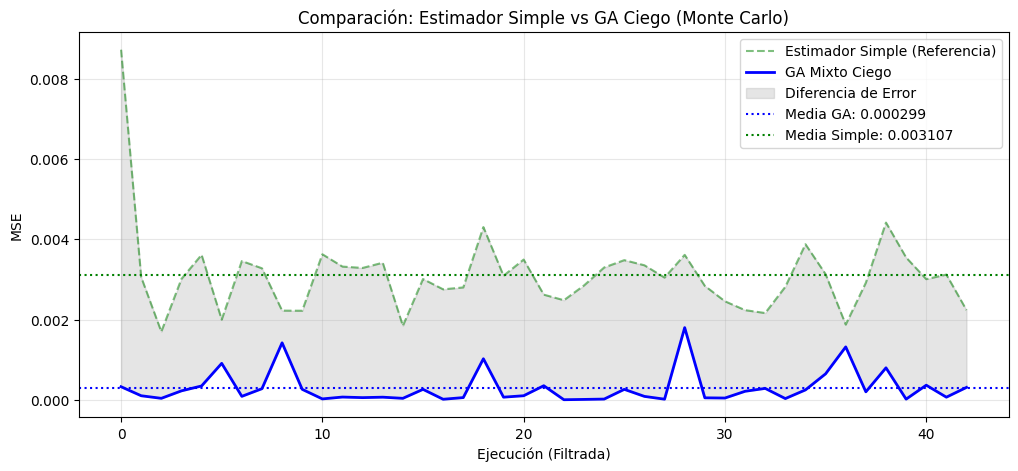

-------------------------------------------------------------------------------------
Puntos eliminados por outlier: 7
MSE MEDIO SIMPLE (Filtrado): 0.00310746
MSE MEDIO GA CIEGO (Filtrado): 0.00029931
Diferencia de precisión: 90.37%
-------------------------------------------------------------------------------------


In [156]:
import matplotlib.pyplot as plt
import numpy as np

# --- 6. GRÁFICO COMPARATIVO Y ESTADÍSTICAS FINALES ---

# SOLUCIÓN AL ERROR: Convertimos las listas a arrays de NumPy
resultados_ga = np.array(resultados_ga)
resultados_simple = np.array(resultados_simple)

# Aplicamos la misma máscara de outliers al estimador simple y a los resultados
# (ga_f ya está filtrado como errores_mse_ga_f en el paso 4)
ga_f = errores_mse_ga_f
sim_f = errores_mse_simple[mask]
res_ga_f = resultados_ga[mask]
res_sim_f = resultados_simple[mask]

# Gráfico
plt.figure(figsize=(12, 5))
x = np.arange(len(ga_f)) # Usamos np.arange por seguridad con fill_between

plt.plot(sim_f, 'g--', alpha=0.5, label='Estimador Simple (Referencia)')
plt.plot(ga_f, 'b-', linewidth=2, label='GA Mixto Ciego')

# Sombreado gris entre las curvas
plt.fill_between(x, ga_f, sim_f, color='gray', alpha=0.2, label='Diferencia de Error')

# Líneas de las medias (usando los datos filtrados)
media_ga_f = np.mean(ga_f)
media_sim_f = np.mean(sim_f)

plt.axhline(y=media_ga_f, color='blue', linestyle=':', label=f'Media GA: {media_ga_f:.6f}')
plt.axhline(y=media_sim_f, color='green', linestyle=':', label=f'Media Simple: {media_sim_f:.6f}')

plt.title('Comparación: Estimador Simple vs GA Ciego (Monte Carlo)')
plt.ylabel('MSE')
plt.xlabel('Ejecución (Filtrada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Estadísticas Finales
print("-" * 85)
print(f"Puntos eliminados por outlier: {n_ejecuciones - len(ga_f)}")
print(f"MSE MEDIO SIMPLE (Filtrado): {media_sim_f:.8f}")
print(f"MSE MEDIO GA CIEGO (Filtrado): {media_ga_f:.8f}")
mejora = (1 - media_ga_f / media_sim_f) * 100
print(f"Diferencia de precisión: {mejora:.2f}%")
print("-" * 85)

#### Gráfico de outliers

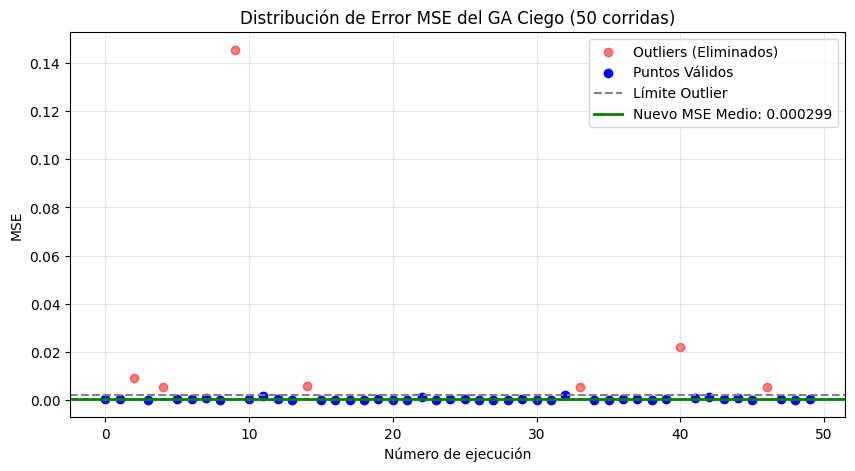


PUNTOS ELIMINADOS (GA): 7
MSE MEDIO ORIGINAL (GA): 0.00422453
MSE MEDIO FILTRADO (GA): 0.00029931
----------------------------------------------------------------------
ESTIMACIONES FINALES GA (PROMEDIO FILTRADO):
A:       0.2546 (Real: 0.25)
Sigma_G2: 0.1009 (Real: 0.1)
Gamma(r): 0.0554 (Real: 0.05)


In [157]:
# --- 7. GRÁFICO DE DISPERSIÓN DE OUTLIERS (GA) ---
plt.figure(figsize=(10, 5))

# Indices de todas las ejecuciones
indices = np.arange(n_ejecuciones)

# Ploteamos los outliers (los que NO cumplen la máscara, es decir ~mask) en rojo
plt.scatter(indices[~mask], errores_mse_ga[~mask], color='red', alpha=0.5, label='Outliers (Eliminados)')

# Ploteamos los puntos válidos (los que SI cumplen la máscara) en azul
plt.scatter(indices[mask], errores_mse_ga_f, color='blue', label='Puntos Válidos')

# Líneas horizontales de referencia
plt.axhline(y=limite_sup, color='gray', linestyle='--', label='Límite Outlier')
plt.axhline(y=mean_mse_ga_f, color='green', linewidth=2, label=f'Nuevo MSE Medio: {mean_mse_ga_f:.6f}')

plt.title(f'Distribución de Error MSE del GA Ciego ({n_ejecuciones} corridas)')
plt.xlabel('Número de ejecución')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 8. ESTADÍSTICAS FINALES DEL GA (PROMEDIOS DE PARÁMETROS) ---
# Extraemos los resultados del GA que pasaron el filtro y promediamos
resultados_ga_f = resultados_ga[mask]
promedios_ga = np.mean(resultados_ga_f, axis=0)

print("\n" + "="*70)
print(f"PUNTOS ELIMINADOS (GA): {n_ejecuciones - len(errores_mse_ga_f)}")
print(f"MSE MEDIO ORIGINAL (GA): {mean_mse_ga:.8f}")
print(f"MSE MEDIO FILTRADO (GA): {mean_mse_ga_f:.8f}")
print("-" * 70)
print(f"ESTIMACIONES FINALES GA (PROMEDIO FILTRADO):")
print(f"A:       {promedios_ga[0]:.4f} (Real: {real_vec[0]})")
print(f"Sigma_G2: {promedios_ga[1]:.4f} (Real: {real_vec[1]})")
print(f"Gamma(r): {promedios_ga[2]:.4f} (Real: {real_vec[2]})")
print("="*70)